# Olist E-Commerce Business Analysis

## Project Objective

This project analyzes Olist e-commerce transaction data to evaluate overall business performance, customer purchasing behavior, geographic performance, product and seller performance, delivery efficiency, customer satisfaction, and payment behavior.

## Business Questions

1. How is the business performing overall?
2. How has sales performance changed over time?
3. Which customer segments and geographic markets generate the most value?
4. Which product categories and sellers perform best?
5. Where are the major delivery-performance problems?
6. How does delivery performance relate to customer satisfaction?
7. What payment methods and installment patterns are most common?

## Analytical Approach

The analysis uses Python, Pandas, NumPy, and Matplotlib to clean, transform, aggregate, analyze, and visualize the Olist datasets. The analysis deliberately separates **item-level metrics** (such as product revenue) from **order-level metrics** (such as delivery time, late-delivery rate, and order-level customer satisfaction) to avoid double-counting orders that contain multiple items.

## Main Analysis Areas

- Business KPIs
- Sales and growth
- Customer behavior
- Geographic performance
- Product and category performance
- Delivery performance
- Seller performance
- Customer satisfaction
- Payment behavior


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
seller_data=pd.read_csv("../Data/Raw/olist_sellers_dataset.csv")
order_items_data=pd.read_csv("../Data/Raw/olist_order_items_dataset.csv")
order_data=pd.read_csv("../Data/Raw/olist_orders_dataset.csv")
customer_data=pd.read_csv("../Data/Raw/olist_customers_dataset.csv")
payment_data=pd.read_csv("../Data/Raw/olist_order_payments_dataset.csv")
product_data=pd.read_csv("../Data/Raw/olist_products_dataset.csv")
review_data=pd.read_csv("../Data/Raw/olist_order_reviews_dataset.csv")
clean_review_data=pd.read_csv("../Data/Processed/reviews_cleaned.csv")
product_category_data=pd.read_csv("../Data/Raw/product_category_name_translation.csv")

 ## Data Transformation

In [34]:
columns=[
    "order_purchase_timestamp",            
     "order_approved_at",
     "order_delivered_carrier_date",  
     "order_delivered_customer_date",    
     "order_estimated_delivery_date"
]
for col in columns:
    order_data[col]=pd.to_datetime(
        order_data[col],format="%d-%m-%Y %H:%M"
    )
    
order_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [35]:
order_data["order_month"]=order_data["order_purchase_timestamp"].dt.month
order_data["order_year"]=order_data["order_purchase_timestamp"].dt.year
order_data["order_period"]=order_data["order_purchase_timestamp"].dt.to_period("M")

order_data["order_delivery_time"]=(order_data["order_delivered_customer_date"]-order_data["order_purchase_timestamp"]).dt.days
order_data["delivery_delay_days"] = (order_data["order_delivered_customer_date"]- order_data["order_estimated_delivery_date"]).dt.days # negative value-early delivery


conditions = [
    order_data["delivery_delay_days"] > 0,
    order_data["delivery_delay_days"] == 0,
    order_data["delivery_delay_days"] < 0
]

choices = ["late", "on-time", "early"]

order_data["Delivery_status"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

order_data

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_year,order_period,order_delivery_time,delivery_delay_days,Delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,10,2017,2017-10,8.0,-8.0,early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,7,2018,2018-07,13.0,-6.0,early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,8,2018,2018-08,9.0,-18.0,early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,11,2017,2017-11,13.0,-13.0,early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2,2018,2018-02,2.0,-10.0,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:00,2017-03-09 09:54:00,2017-03-10 11:18:00,2017-03-17 15:08:00,2017-03-28,3,2017,2017-03,8.0,-11.0,early
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:00,2018-02-06 13:10:00,2018-02-07 23:22:00,2018-02-28 17:37:00,2018-03-02,2,2018,2018-02,22.0,-2.0,early
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:00,2017-08-27 15:04:00,2017-08-28 20:52:00,2017-09-21 11:24:00,2017-09-27,8,2017,2017-08,24.0,-6.0,early
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:00,2018-01-08 21:36:00,2018-01-12 15:35:00,2018-01-25 23:32:00,2018-02-15,1,2018,2018-01,17.0,-21.0,early


## Sales Analysis Datasets

In [36]:
sales_analysis_dataset = (
    order_data[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivery_time",
            "delivery_delay_days"
        ]
    ]
    .merge(
        order_items_data[
            [
                "order_id",
                "product_id",
                "seller_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        product_data[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
            product_category_data[
                [
                    "product_category_name",
                    "product_category_name_english"
                ]
            ],
            on="product_category_name",
            how="left"
        )
    .merge(
        seller_data[
            [
                "seller_id",
                "seller_state",
                "seller_city"
            ]
        ],
        on="seller_id",
        how="left"
    )
    .merge(
        customer_data[
            [
                "customer_id",
                "customer_unique_id",
                "customer_state",
                "customer_city"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

sales_analysis_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivery_time,delivery_delay_days,product_id,seller_id,price,freight_value,product_category_name,product_category_name_english,seller_state,seller_city,customer_unique_id,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,8.0,-8.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas,housewares,SP,maua,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,13.0,-6.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria,perfumery,SP,belo horizonte,af07308b275d755c9edb36a90c618231,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,9.0,-18.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo,auto,SP,guariba,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,13.0,-13.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop,pet_shop,MG,belo horizonte,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2.0,-10.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria,stationery,SP,mogi das cruzes,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre


In [37]:
sales_analysis_dataset.to_csv(
    "../Data/Final/sales_analysis_dataset.csv",
    index=False
)

## Delivery Analysis Dataset

In [38]:
delivery_analysis_dataset = (
    order_data[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "order_delivery_time",
            "delivery_delay_days",
            "Delivery_status"
        ]
    ]
    .merge(
        customer_data[
            [
                "customer_id",
                "customer_unique_id",
                "customer_state",
                "customer_city",
                "customer_type"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

delivery_analysis_dataset.head()

KeyError: "['customer_type'] not in index"

In [ ]:
# print(delivery_analysis_dataset["order_id"].nunique())
# print(delivery_analysis_dataset["order_id"].count())
# print(customer_satisfaction_dataset["order_id"].nunique())
# print(customer_satisfaction_dataset["order_id"].count())
# print(delivery_analysis_dataset["order_id"].nunique())
# print(delivery_analysis_dataset["order_id"].count())

In [ ]:
delivery_analysis_dataset.to_csv(
    "../Data/Final/delivery_analysis_dataset.csv",
    index=False
)

## Customer Satisfaction Dataset

In [ ]:
customer_satisfaction_dataset = (
    order_data[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "order_delivery_time",
            "delivery_delay_days",
            "Delivery_status"
        ]
    ]
    .merge(
        customer_data[
            [
                "customer_id",
                "customer_unique_id",
                "customer_state",
                "customer_city",
                "customer_type"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        clean_review_data[
            [
                "order_id",
                "review_id",
                "review_score",
                "review_type"
            ]
        ],
        on="order_id",
        how="left"
    )
    
    .merge(
        order_items_data[
            [
                "order_id",
                "product_id",
                "seller_id",
                "price",
                "freight_value"
            ]
        ],
        on="order_id",
        how="left"      
    )
    .merge(
            product_data[
                [
                    "product_id",
                    "product_category_name"
                ]
            ],
            on="product_id",
            how="left"
        )
)

customer_satisfaction_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_delivery_time,delivery_delay_days,Delivery_status,customer_unique_id,...,customer_city,customer_type,review_id,review_score,review_type,product_id,seller_id,price,freight_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-10 21:25:00,2017-10-18,8.0,-8.0,early,7c396fd4830fd04220f754e42b4e5bff,...,sao paulo,unknown,a54f0611adc9ed256b57ede6b6eb5114,4.0,Positive,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-08-07 15:27:00,2018-08-13,13.0,-6.0,early,af07308b275d755c9edb36a90c618231,...,barreiras,unknown,8d5266042046a06655c8db133d120ba5,4.0,Positive,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-17 18:06:00,2018-09-04,9.0,-18.0,early,3a653a41f6f9fc3d2a113cf8398680e8,...,vianopolis,unknown,e73b67b67587f7644d5bd1a52deb1b01,5.0,Positive,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-12-02 00:28:00,2017-12-15,13.0,-13.0,early,7c142cf63193a1473d2e66489a9ae977,...,sao goncalo do amarante,unknown,359d03e676b3c069f62cadba8dd3f6e8,5.0,Positive,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-16 18:17:00,2018-02-26,2.0,-10.0,early,72632f0f9dd73dfee390c9b22eb56dd6,...,santo andre,unknown,e50934924e227544ba8246aeb3770dd4,5.0,Positive,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,19.90,8.72,papelaria


In [ ]:
customer_satisfaction_dataset.to_csv(
    "../Data/Final/customer_satisfaction_dataset.csv",
    index=False
)

In [ ]:
payment_analysis_dataset = (
    payment_data[
        [
            "order_id",
            "payment_sequential",
            "payment_type",
            "payment_installments",
            "payment_value"
        ]
    ]
    .merge(
        order_data[
            [
                "order_id",
                "customer_id",
                "order_status",
                "order_purchase_timestamp"
            ]
        ],
        on="order_id",
        how="left"
    )
)

payment_analysis_dataset.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,0a8556ac6be836b46b3e89920d59291c,delivered,2018-04-25 22:01:00
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,f2c7fc58a9de810828715166c672f10a,delivered,2018-06-26 11:01:00
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,25b14b69de0b6e184ae6fe2755e478f9,delivered,2017-12-12 11:19:00
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,7a5d8efaaa1081f800628c30d2b0728f,delivered,2017-12-06 12:04:00
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,15fd6fb8f8312dbb4674e4518d6fa3b3,delivered,2018-05-21 13:59:00


In [ ]:
payment_analysis_dataset.to_csv(
    "../Data/Final/payment_analysis_dataset.csv",
    index=False
)


## ORDER-LEVEL ANALYSIS DATASETS

The item-level delivery and satisfaction datasets above are retained for product/category analysis. The following datasets are used whenever the business metric should be measured at order level.


In [ ]:
order_delivery_level = order_data[
    ["order_id", "customer_id", "order_purchase_timestamp",
     "order_delivered_customer_date", "order_estimated_delivery_date",
     "order_delivery_time", "delivery_delay_days", "Delivery_status"]
].copy()

order_delivery_level = order_delivery_level.drop_duplicates("order_id")

order_delivery_level = order_delivery_level.merge(
    customer_data[["customer_id", "customer_unique_id", "customer_state", "customer_city"]],
    on="customer_id",
    how="left"
)

order_review_level = (
    review_data.groupby("order_id", as_index=False)["review_score"]
    .mean()
)

order_satisfaction_level = order_delivery_level.merge(
    order_review_level,
    on="order_id",
    how="left"
)

# One row per seller-order pair. This prevents multi-item orders from receiving extra weight in seller delivery/review metrics.

seller_order_level = (
    order_delivery_level[["order_id", "order_delivery_time",
                          "delivery_delay_days", "Delivery_status"]]
    .merge(
        order_items_data[["order_id", "seller_id"]].drop_duplicates(),
        on="order_id",
        how="inner"
    )
)

print("Order-level delivery records:", order_delivery_level["order_id"].nunique())
print("Order-level satisfaction records:", order_satisfaction_level["order_id"].nunique())


Order-level delivery records: 99441
Order-level satisfaction records: 99441


In [ ]:
# Revenue per customer
revenue_per_customer = (
    order_items_data["price"].sum()
    / customer_data["customer_unique_id"].nunique()
)

# Repeat purchase rate
customer_order_count = (
    order_data
    .merge(
        customer_data[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_purchase_rate = (
    (customer_order_count > 1).mean() * 100
)

# Average items per order
average_items_per_order = (
    order_items_data.groupby("order_id")
    .size()
    .mean()
)

# Late delivery rate
late_delivery_rate = (
    delivery_analysis_dataset["delivery_delay_days"] > 0
).mean() * 100


## BUSINESS KEY PERFORMANCE INDICATORS (KPIs)
Delivery KPIs are calculated from the order-level dataset so that an order
with multiple items is counted once.

In [ ]:
delivered_orders = order_delivery_level[
    order_delivery_level["Delivery_status"] != "Unknown"
].copy()

order_level_late_rate = (
    (delivered_orders["Delivery_status"] == "late").mean() * 100
)

order_level_avg_delivery_time = delivered_orders["order_delivery_time"].mean()

business_kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Average Order Value",
        "Revenue per Customer",
        "Repeat Purchase Rate (%)",
        "Average Items per Order",
        "Average Review Score",
        "Average Delivery Time (Days)",
        "Late Delivery Rate (%)"
    ],
    "Value": [
        order_items_data["price"].sum(),
        order_data["order_id"].nunique(),
        customer_data["customer_unique_id"].nunique(),
        seller_data["seller_id"].nunique(),
        order_items_data.groupby("order_id")["price"].sum().mean(),
        revenue_per_customer,
        repeat_purchase_rate,
        average_items_per_order,
        review_data["review_score"].mean(),
        order_level_avg_delivery_time,
        order_level_late_rate
    ]
})

business_kpis["Value"] = business_kpis["Value"].apply(
    lambda x: f"{x:,.2f}"
)

business_kpis


,KPI,Value
0,Total Revenue,"13,591,643.70"
1,Total Orders,"99,441.00"
2,Total Customers,"96,096.00"
3,Total Sellers,"3,095.00"
4,Average Order Value,137.75
5,Revenue per Customer,141.44
6,Repeat Purchase Rate (%),3.12
7,Average Items per Order,1.14
8,Average Review Score,4.09
9,Average Delivery Time (Days),12.09


## TIME SERIES ANALYSIS: MONTHLY BUSINESS PERFORMANCE

In [ ]:
order_data["order_purchase_timestamp"] = pd.to_datetime(
    order_data["order_purchase_timestamp"]
)

# Monthly orders
monthly_orders = (
    order_data
    .set_index("order_purchase_timestamp") # resample is used after setting a datetime column as the index: resample() groups time-series data according to a specified time frequency.means: Group the data by each calendar month, using month-end (ME) frequency.
    .resample("ME")["order_id"] #ME means Month End.It creates monthly groups.It is important to understand that "ME" does not select only orders placed on the last day of the month. It groups all dates within each month.January 2017 → all order_id values in January
    .nunique()
    .rename("Total_Orders")
)

# Monthly customers
monthly_customers = (
    order_data
    .set_index("order_purchase_timestamp")
    .resample("ME")["customer_id"]
    .nunique()
    .rename("Total_Customers")
)

# Monthly revenue
monthly_revenue_data = (
    order_items_data
    .merge(
        order_data[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="inner"
    )
)

monthly_revenue_data["order_purchase_timestamp"] = pd.to_datetime(
    monthly_revenue_data["order_purchase_timestamp"]
)

monthly_revenue = (
    monthly_revenue_data
    .set_index("order_purchase_timestamp")
    .resample("ME")["price"]
    .sum()
    .rename("Total_Revenue")
)

# Combine all monthly metrics
monthly_performance = pd.concat(
    [monthly_orders, monthly_revenue, monthly_customers],
    axis=1
).reset_index()

monthly_performance.head()

,order_purchase_timestamp,Total_Orders,Total_Revenue,Total_Customers
0,2016-09-30,4,267.36,4
1,2016-10-31,324,49507.66,324
2,2016-11-30,0,0.00,0
3,2016-12-31,1,10.90,1
4,2017-01-31,800,120312.87,800


In [ ]:
# The first months of the dataset contain very few orders, which can create
# misleading extreme growth rates. Use January 2017 onward for the main
# growth analysis while retaining the full raw data for other analyses.


monthly_performance = monthly_performance[
    monthly_performance["order_purchase_timestamp"] >= pd.Timestamp("2017-01-01")
].copy()

monthly_performance


,order_purchase_timestamp,Total_Orders,Total_Revenue,Total_Customers
4,2017-01-31,800,120312.87,800
5,2017-02-28,1780,247303.02,1780
6,2017-03-31,2682,374344.30,2682
7,2017-04-30,2404,359927.23,2404
8,2017-05-31,3700,506071.14,3700
9,2017-06-30,3245,433038.60,3245
10,2017-07-31,4026,498031.48,4026
11,2017-08-31,4331,573971.68,4331
12,2017-09-30,4285,624401.69,4285
13,2017-10-31,4631,664219.43,4631


## MONTH-OVER-MONTH (MoM) GROWTH

In [ ]:
# Keep growth columns numeric so they remain usable for sorting, filtering, calculations, and visualizations. Formatting is applied only at presentation time.

monthly_performance["Order_MoM_Growth (%)"] = monthly_performance["Total_Orders"].pct_change() * 100
monthly_performance["Revenue_MoM_Growth (%)"] = monthly_performance["Total_Revenue"].pct_change() * 100
monthly_performance["Customer_MoM_Growth (%)"] = monthly_performance["Total_Customers"].pct_change() * 100

monthly_performance.head()


,order_purchase_timestamp,Total_Orders,Total_Revenue,Total_Customers,Order_MoM_Growth (%),Revenue_MoM_Growth (%),Customer_MoM_Growth (%)
4,2017-01-31,800,120312.87,800,NaN,NaN,NaN
5,2017-02-28,1780,247303.02,1780,122.500000,105.549930,122.500000
6,2017-03-31,2682,374344.30,2682,50.674157,51.370695,50.674157
7,2017-04-30,2404,359927.23,2404,-10.365399,-3.851286,-10.365399
8,2017-05-31,3700,506071.14,3700,53.910150,40.603738,53.910150


## YEAR-OVER-YEAR (YoY) GROWTH

In [ ]:
# Keep growth columns numeric for reliable analysis.

monthly_performance["Order_YoY_Growth (%)"] = monthly_performance["Total_Orders"].pct_change(periods=12) * 100
monthly_performance["Revenue_YoY_Growth (%)"] = monthly_performance["Total_Revenue"].pct_change(periods=12) * 100
monthly_performance["Customer_YoY_Growth (%)"] = monthly_performance["Total_Customers"].pct_change(periods=12) * 100

monthly_performance.head()


,order_purchase_timestamp,Total_Orders,Total_Revenue,Total_Customers,Order_MoM_Growth (%),Revenue_MoM_Growth (%),Customer_MoM_Growth (%),Order_YoY_Growth (%),Revenue_YoY_Growth (%),Customer_YoY_Growth (%)
4,2017-01-31,800,120312.87,800,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-02-28,1780,247303.02,1780,122.500000,105.549930,122.500000,NaN,NaN,NaN
6,2017-03-31,2682,374344.30,2682,50.674157,51.370695,50.674157,NaN,NaN,NaN
7,2017-04-30,2404,359927.23,2404,-10.365399,-3.851286,-10.365399,NaN,NaN,NaN
8,2017-05-31,3700,506071.14,3700,53.910150,40.603738,53.910150,NaN,NaN,NaN


## CREATE TIME VARIABLES

In [ ]:
monthly_performance["Year"] = (
    monthly_performance["order_purchase_timestamp"].dt.year
)

monthly_performance["Month"] = (
    monthly_performance["order_purchase_timestamp"].dt.month
)

monthly_performance["Month_Name"] = (
    monthly_performance["order_purchase_timestamp"].dt.month_name()
)

monthly_performance.head()

,order_purchase_timestamp,Total_Orders,Total_Revenue,Total_Customers,Order_MoM_Growth (%),Revenue_MoM_Growth (%),Customer_MoM_Growth (%),Order_YoY_Growth (%),Revenue_YoY_Growth (%),Customer_YoY_Growth (%),Year,Month,Month_Name
4,2017-01-31,800,120312.87,800,NaN,NaN,NaN,NaN,NaN,NaN,2017,1,January
5,2017-02-28,1780,247303.02,1780,122.500000,105.549930,122.500000,NaN,NaN,NaN,2017,2,February
6,2017-03-31,2682,374344.30,2682,50.674157,51.370695,50.674157,NaN,NaN,NaN,2017,3,March
7,2017-04-30,2404,359927.23,2404,-10.365399,-3.851286,-10.365399,NaN,NaN,NaN,2017,4,April
8,2017-05-31,3700,506071.14,3700,53.910150,40.603738,53.910150,NaN,NaN,NaN,2017,5,May


## SEASONALITY ANALYSIS

In [ ]:
seasonality_analysis = (
    monthly_performance
    .groupby(["Month", "Month_Name"])
    .agg(
        Avg_Monthly_Orders=("Total_Orders", "mean"),
        Avg_Monthly_Revenue=("Total_Revenue", "mean"),
        Avg_Monthly_Customers=("Total_Customers", "mean")
    )
    .reset_index()
    .sort_values("Month")
)

seasonality_analysis

,Month,Month_Name,Avg_Monthly_Orders,Avg_Monthly_Revenue,Avg_Monthly_Customers
0,1,January,4034.5,535171.615,4034.5
1,2,February,4254.0,545740.865,4254.0
2,3,March,4946.5,678778.870,4946.5
3,4,April,4671.5,678287.490,4671.5
4,5,May,5286.5,751294.410,5286.5
5,6,June,4706.0,649081.455,4706.0
6,7,July,5159.0,696769.350,5159.0
7,8,August,5421.5,714329.005,5421.5
8,9,September,2150.5,312273.345,2150.5
9,10,October,2317.5,664219.430,2317.5


## MAJOR SPIKES AND DECLINES

In [ ]:
# Orders

highest_order_growth = monthly_performance.loc[
    monthly_performance["Order_MoM_Growth (%)"].idxmax()
]

largest_order_decline = monthly_performance.loc[
    monthly_performance["Order_MoM_Growth (%)"].idxmin()
]

# Revenue
highest_revenue_growth = monthly_performance.loc[
    monthly_performance["Revenue_MoM_Growth (%)"].idxmax()
]

largest_revenue_decline = monthly_performance.loc[
    monthly_performance["Revenue_MoM_Growth (%)"].idxmin()
]

print("Highest Order Growth:")
print(highest_order_growth[
    ["order_purchase_timestamp", "Order_MoM_Growth (%)"]
])

print("\nLargest Order Decline:")
print(largest_order_decline[
    ["order_purchase_timestamp", "Order_MoM_Growth (%)"]
])

print("\nHighest Revenue Growth:")
print(highest_revenue_growth[
    ["order_purchase_timestamp", "Revenue_MoM_Growth (%)"]
])

print("\nLargest Revenue Decline:")
print(largest_revenue_decline[
    ["order_purchase_timestamp", "Revenue_MoM_Growth (%)"]
])

Highest Order Growth:
order_purchase_timestamp    2017-02-28 00:00:00
Order_MoM_Growth (%)                      122.5
Name: 5, dtype: object

Largest Order Decline:
order_purchase_timestamp    2018-09-30 00:00:00
Order_MoM_Growth (%)                   -99.7543
Name: 24, dtype: object

Highest Revenue Growth:
order_purchase_timestamp    2017-02-28 00:00:00
Revenue_MoM_Growth (%)                105.54993
Name: 5, dtype: object

Largest Revenue Decline:
order_purchase_timestamp    2018-09-30 00:00:00
Revenue_MoM_Growth (%)               -99.983035
Name: 24, dtype: object


## Customer Analysis

In [ ]:
customer_analysis = (
    sales_analysis_dataset.groupby("customer_unique_id")
    .agg(
        number_of_orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
)

customer_analysis["avg_order_value"] = (
    customer_analysis["revenue"] /
    customer_analysis["number_of_orders"]
)

conditions=(customer_analysis["number_of_orders"]>1,customer_analysis["number_of_orders"]==1)
choice=("Repeated-customers","One-Time-Customers")

customer_analysis["customer_type"] = np.select(conditions,choice,default="unknown")

customer_analysis.sort_values(
    ["revenue","avg_order_value"],
    ascending=[False,False]
)

# The customer-level analysis shows the purchasing behavior and value of each distinct customer by measuring their number of orders, total revenue, 
# average order value, and customer type. The customer 0a0a92112bd4c708ca5fde585afaa872 generated the highest revenue of 13,440.0 and also had the 
# highest average order value of 13,440.0. Since this customer placed only one order, they are classified as a one-time customer.

,number_of_orders,revenue,avg_order_value,customer_type
customer_unique_id,,,,
0a0a92112bd4c708ca5fde585afaa872,1,13440.0,13440.0,One-Time-Customers
da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,3694.0,Repeated-customers
763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,7160.0,One-Time-Customers
dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,6735.0,One-Time-Customers
459bef486812aa25204be022145caa62,1,6729.0,6729.0,One-Time-Customers
...,...,...,...,...
feb643dc81ca576d83810f147e0e089c,1,0.0,0.0,One-Time-Customers
fec36733d170d71e390acde47d74c6d6,1,0.0,0.0,One-Time-Customers
ff222edf83338ca6b35f8e29871fa07a,1,0.0,0.0,One-Time-Customers


In [ ]:
repeat_vs_onetime = (
    customer_analysis.groupby("customer_type")
    .agg(
        number_of_customers=("customer_type", "size"),
        avg_number_of_orders=("number_of_orders", "mean"),
        avg_revenue=("revenue", "mean"),
        avg_order_value=("avg_order_value", "mean")
    )
)

repeat_vs_onetime

# This analysis compares the purchasing behavior of one-time and repeated customers. One-time customers represent the majority of the customer base, 
# with 93,099 customers, and each customer placed an average of 1 order. They have an average revenue and average order value of 137.63. 

# In comparison repeated customers account for 2,997 customers and placed an average of approximately 2.12 orders per customer. Repeated customers 
# generated the higher average revenue of 259.87, while one-time customers had the higher average order value of 137.63.


,number_of_customers,avg_number_of_orders,avg_revenue,avg_order_value
customer_type,,,,
One-Time-Customers,93099,1.000000,137.625772,137.625772
Repeated-customers,2997,2.116116,259.867191,122.802287


In [ ]:
# Repeat customer rate
repeat_customer_rate = (
    repeat_vs_onetime.loc["Repeated-customers", "number_of_customers"]
    / repeat_vs_onetime["number_of_customers"].sum()
    * 100
)

# One-time customer rate
one_time_customer_rate = (
    repeat_vs_onetime.loc["One-Time-Customers", "number_of_customers"]
    / repeat_vs_onetime["number_of_customers"].sum()
    * 100
)

print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")
print(f"One-Time Customer Rate: {one_time_customer_rate:.2f}%")

# The analysis evaluates customer retention by measuring the proportion of unique customers who placed more than one order. Customers with more than 
# one distinct order are classified as repeat customers, while customers with only one order are classified as one-time customers.

# The analysis shows that the repeat customer rate is 3.12%, while 96.88% of customers are one-time customers. This indicates that the business has a 
# very low level of observed repeat purchasing within the available dataset.The result suggests a potential customer retention concern, as the vast 
# majority of customers did not place another recorded order. 

# The business therefore appears to rely heavily on acquiring new customers rather than generating repeat purchases from existing customers.However, 
# this result alone does not definitively prove a retention problem. Some customers may not have had sufficient time to make another purchase before 
# the dataset ended. Further analysis of customer cohorts and purchase timing would be needed to measure true retention accurately.

Repeat Customer Rate: 3.12%
One-Time Customer Rate: 96.88%


## Customer State Analysis

In [ ]:
customer_state_analysis=(sales_analysis_dataset.groupby("customer_state")
                         .agg(
                             customer_count=("customer_unique_id","nunique"),
                             revenue=("price","sum")
                         )
                        )

customer_state_analysis["avg_revenue_per_customer"]=customer_state_analysis["revenue"]/customer_state_analysis["customer_count"]
customer_state_analysis.sort_values("revenue",ascending=False)

# SP is the largest market in this analysis based on customer count and total revenue, with 40,302 unique customers and approximately 5.20 million in 
# revenue. Its average revenue per customer is approximately 129.10, which is comparatively low across the states. This indicates that SP's strong 
# total revenue is associated with its substantially larger customer base rather than high revenue generated per customer.

# RJ and MG are the next-largest markets by both customer base and total revenue. RJ has 12,384 customers and generates approximately 1.82 million in 
# revenue, while MG has 11,259 customers and generates approximately 1.59 million. Their average revenue per customer, approximately 147.29 and 140.80
# respectively, is higher than SP's.

# Several smaller markets have relatively high average revenue per customer. PB has the highest value at approximately 222.10, followed by AC at 
# 207.57, AP at 201.11, AL at 200.29, and RO at 192.25. Although these states have smaller customer bases and lower total revenue, they generate more 
# revenue per customer on average.

# Overall, the analysis reveals two different market patterns: SP is the largest market based on customer volume and total revenue, whereas states 
# such as PB, AC, AP, and AL represent relatively high-value markets based on average revenue per customer. The business could further investigate 
# whether these high-value markets offer opportunities to increase the customer base while maintaining their higher average customer value.

,customer_count,revenue,avg_revenue_per_customer
customer_state,,,
SP,40302,5202955.05,129.099177
RJ,12384,1824092.67,147.294305
MG,11259,1585308.03,140.803626
RS,5277,750304.02,142.183820
PR,4882,683083.76,139.918837
SC,3534,520553.34,147.298625
BA,3277,511349.99,156.042109
DF,2075,302603.94,145.833224
GO,1952,294591.95,150.918007


In [ ]:
relation=customer_state_analysis[
    ["customer_count","avg_revenue_per_customer"]
    ].corr()
relation

# This analysis shows a moderate negative correlation of approximately -0.52
# between customer count and average revenue per customer. This indicates that
# states with higher customer counts tend to have lower average revenue per
# customer, while states with lower customer counts tend to have higher average
# revenue per customer. However, this correlation does not prove causation.

# There is a moderate negative association in this state-level dataset, but this 
# result should be interpreted cautiously because the analysis contains a relatively
# small number of geographic observations and may be influenced by individual states."

,customer_count,avg_revenue_per_customer
customer_count,1.000000,-0.521483
avg_revenue_per_customer,-0.521483,1.000000


## CUSTOMER STATE DELIVERY PERFORMANCE (ORDER LEVEL)

In [ ]:
state_delivery_data = order_delivery_level[
    ["customer_state", "order_id", "order_delivery_time",
     "delivery_delay_days", "Delivery_status"]
].copy()

customer_state_delivery = (
    state_delivery_data.groupby("customer_state")
    .agg(
        avg_delivery_time=("order_delivery_time", "mean"),
        avg_order_delay=("delivery_delay_days", "mean"),
        Total_orders=("order_id", "nunique"),
        late_orders=("Delivery_status", lambda x: (x == "late").sum())
    )
)

customer_state_delivery["delay_rate"] = (
    customer_state_delivery["late_orders"]
    / customer_state_delivery["Total_orders"]
    * 100
)

customer_state_delivery


,avg_delivery_time,avg_order_delay,Total_orders,late_orders,delay_rate
customer_state,,,,,
AC,20.637500,-20.725000,81,3,3.703704
AL,24.040302,-8.707809,413,85,20.581114
AM,25.986207,-19.565517,148,4,2.702703
AP,26.731343,-19.686567,68,2,2.941176
BA,18.866400,-10.794533,3380,396,11.715976
CE,20.817826,-10.804535,1336,176,13.173653
DF,12.509135,-12.048077,2140,118,5.514019
ES,15.331830,-10.496241,2033,214,10.526316
GO,15.151763,-12.185488,2020,128,6.336634


## Product Categories with Longer Average Delivery Times


In [ ]:
customer_state_worst_delivery=customer_state_delivery[
    (customer_state_delivery["avg_delivery_time"]>customer_state_delivery["avg_delivery_time"].mean())&
    (customer_state_delivery["avg_order_delay"]>customer_state_delivery["avg_order_delay"].mean())&
    (customer_state_delivery["delay_rate"]>customer_state_delivery["delay_rate"].mean())
]

customer_state_worst_delivery.sort_values(
    ["delay_rate", "avg_delivery_time"],
    ascending=False
)

# The analysis identifies AL, MA, SE, PI, CE, BA, and PB as states with relatively weak overall delivery performance because all three of their 
# delivery metrics—average delivery time, average order delay, and delay rate—are above the respective overall averages according to the filtering
# criteria.

# Among these states, AL appears to be the most critical, with the highest late-delivery rate of 20.58% and the longest average delivery time of 
# approximately 24.040302 days. MA also shows significant delivery concerns, with a late-delivery rate of approximately 16.73%. These states could be 
# prioritized for further investigation to determine whether factors such as logistics operations, seller performance, or delivery coverage are 
# contributing to the weaker delivery results.

# Within this identified group, BA has the lowest average delivery time at approximately 19.95 days, while PB has the lowest delay rate at approximate
# 10.07%. However, these values are still included in the weak-delivery group because each state meets all the filtering conditions defined in the 
# analysis.

,avg_delivery_time,avg_order_delay,Total_orders,late_orders,delay_rate
customer_state,,,,,
AL,24.040302,-8.707809,413,85,20.581114
MA,21.117155,-9.571827,747,125,16.733601
SE,21.029851,-10.020896,350,51,14.571429
PI,18.993697,-11.306723,495,66,13.333333
CE,20.817826,-10.804535,1336,176,13.173653
BA,18.866400,-10.794533,3380,396,11.715976
PB,19.953578,-13.261122,536,54,10.074627


## Product Performance

In [ ]:
product_performance=(sales_analysis_dataset.groupby("product_id")
                      .agg(
                          Total_revenue=("price","sum"),
                          Total_sales=("product_id","size"),       #counts how many times that product appears in the dataset.
                          Avg_product_price=("price","mean"),
                          Total_order_count=("order_id","nunique")  #counts the number of unique orders containing that product.
                      ))

product_performance.sort_values(
    ["Total_sales"],
    ascending=[False]
)

# This analysis evaluates individual product performance using total revenue, total sales, average product price, and total order count. The product 
# aca2eb7d00ea1a7b8ebd4e68314663af generated the highest total revenue of 37608.90 among the products shown and recorded the highest total sales of 
# 527, while 002959d7a0b0990fe2d69988affcbc80 had the highest average product price of approximately 129.900000  
# This shows that product performance differs depending on the metric being considered.

,Total_revenue,Total_sales,Avg_product_price,Total_order_count
product_id,,,,
aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,527,71.364137,431
99a4788cb24856965c36a24e339b6058,43025.56,488,88.167131,467
422879e10f46682990de24d770e7f83d,26577.22,484,54.911612,352
389d119b48cf3043d311335e499d9c6b,21440.59,392,54.695383,311
368c6c730842d78016ad823897a372db,21056.80,388,54.270103,291
...,...,...,...,...
ffd7628b0b0b98ebc549e8e4c54a59af,79.90,1,79.900000,1
ffd63ee42a5c8cc5a15a1c8e2aa50011,77.00,1,77.000000,1
002959d7a0b0990fe2d69988affcbc80,129.90,1,129.900000,1


## Product_Category_Performance

In [ ]:
product_category_performance=(sales_analysis_dataset.groupby("product_category_name")
                      .agg(
                          Total_revenue=("price","sum"),
                          Total_sales=("product_category_name","size"),  
                          Avg_product_category_price=("price","mean"),
                          Total_freight_value=("freight_value","sum")   
                      ))
product_category_performance.sort_values("Avg_product_category_price",ascending=False)

# This analysis evaluates product category performance using total revenue, total sales, average product price, and total freight value. 

# pcs category generate the highest revenue 222963.13 and also generate the highest Avg_product_category_price 1098.340542,instrumentos_musicais have
# the highest sales 680 and also generated the highest freight value 18638.49 

,Total_revenue,Total_sales,Avg_product_category_price,Total_freight_value
product_category_name,,,,
pcs,222963.13,203,1098.340542,9836.30
portateis_casa_forno_e_cafe,47445.71,76,624.285658,2747.86
eletrodomesticos_2,113317.74,238,476.124958,10600.18
agro_industria_e_comercio,72530.47,212,342.124858,5843.60
instrumentos_musicais,191498.88,680,281.616000,18638.49
...,...,...,...,...
alimentos_bebidas,15179.48,278,54.602446,4507.99
cds_dvds_musicais,730.00,14,52.142857,224.99
fraldas_higiene,1567.59,39,40.194615,573.68


In [ ]:
# Add late delivery performance metrics at category level

category_delivery_metrics = (
    sales_analysis_dataset
    .groupby("product_category_name")
    .agg(
        Total_orders=("order_id", "nunique"),
        Late_orders=("delivery_delay_days", lambda x: (x > 0).sum()),
        Late_delivery_rate=("delivery_delay_days", lambda x: (x > 0).mean() * 100),
        Avg_delivery_time=("order_delivery_time", "mean"),
        Avg_delay_days=("delivery_delay_days", "mean")
    )
)

category_delivery_metrics.sort_values(
    "Late_delivery_rate",
    ascending=False
)

,Total_orders,Late_orders,Late_delivery_rate,Avg_delivery_time,Avg_delay_days
product_category_name,,,,,
casa_conforto_2,24,4,13.333333,14.066667,-8.433333
moveis_colchao_e_estofado,38,5,13.157895,13.891892,-7.162162
audio,350,42,11.538462,12.883978,-10.149171
artigos_de_natal,128,15,9.803922,15.300000,-12.053333
casa_conforto,397,40,9.216590,13.039627,-9.811189
...,...,...,...,...,...
cds_dvds_musicais,12,0,0.000000,10.357143,-16.857143
fraldas_higiene,27,0,0.000000,10.243243,-11.351351
la_cuisine,13,0,0.000000,7.071429,-16.357143


## Product Category that has poor/worst delivery performance

In [ ]:
product_category_delivery_performance=(
    sales_analysis_dataset.groupby("product_category_name")
    .agg(
        delivery_time=("order_delivery_time", "mean"),
        delivery_delay=("delivery_delay_days", "mean")
    )
)

product_category_poor_delivery_performance=product_category_delivery_performance[
    (product_category_delivery_performance["delivery_time"]>product_category_delivery_performance["delivery_time"].mean())&
    (product_category_delivery_performance["delivery_delay"]>product_category_delivery_performance["delivery_delay"].mean())
    ]

product_category_poor_delivery_performance.sort_values(
    ["delivery_time","delivery_delay"],
    ascending=False)


# The analysis identifies product categories whose average delivery time and average delivery delay are above the respective overall category averages
# according to the defined filtering criteria. moveis_escritorio has the highest average delivery time among the identified categories, at approximate
# ly 20.38 days, followed by artigos_de_natal at approximately 15.30 days.

# Based on the stated definition that positive delivery-delay values indicate late delivery and negative values indicate early delivery, all the 
# identified categories have negative average delivery-delay values. Therefore, their average deliveries are still earlier than the estimated delivery
# dates. Among the displayed categories, moveis_colchao_e_estofado has the value closest to zero at approximately -7.16 days, meaning it is the least
# early among these categories, while artigos_de_natal has the most negative value at approximately -12.05 days.

# Overall, moveis_escritorio is the clearest category requiring attention from a delivery-speed perspective because it has the highest average delivery 
# time in this filtered group. Further investigation could examine whether factors such as product characteristics, seller location, shipment distance
# or logistics complexity are associated with its longer delivery time.

,delivery_time,delivery_delay
product_category_name,,
moveis_escritorio,20.387290,-11.845923
artigos_de_natal,15.300000,-12.053333
casa_conforto_2,14.066667,-8.433333
moveis_colchao_e_estofado,13.891892,-7.162162
moveis_sala,13.294949,-11.800000
fashion_underwear_e_moda_praia,13.275591,-10.929134
ferramentas_jardim,13.232193,-11.975867
consoles_games,13.145087,-11.679522
pcs,13.050251,-11.577889


## ORDER DELIVERY PERFORMANCE

In [ ]:
order_delivery_performance = (
    order_delivery_level.groupby("order_id")
    .agg(
        delivery_time=("order_delivery_time", "first"),
        delivery_delay=("delivery_delay_days", "first"),
        delivery_status=("Delivery_status", "first")
    )
)

order_delivery_performance


,delivery_time,delivery_delay,delivery_status
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,7.0,-9.0,early
00018f77f2f0320c557190d7a144bdd3,16.0,-3.0,early
000229ec398224ef6ca0657da4fc703e,7.0,-14.0,early
00024acbcdf0a6daa1e931b038114c75,6.0,-6.0,early
00042b26cf59d7ce69dfabb4e55b4fd9,25.0,-16.0,early
...,...,...,...
fffc94f6ce00a00581880bf54a75a037,17.0,-8.0,early
fffcd46ef2263f404302a634eb57f7eb,9.0,-9.0,early
fffce4705a9662cd70adb13d4a31832d,4.0,-13.0,early


In [ ]:
delivery_status_count = order_delivery_performance[
    "delivery_status"
].value_counts()

delivery_status_count


# The analysis shows that most orders (88,649) were delivered early compared
# with their estimated delivery dates. A total of 6,535 orders were delivered
# late, representing an area of delivery performance that requires further
# investigation. Further analysis could examine whether factors such as seller
# performance, customer location, product category, and regional delivery
# patterns are associated with late deliveries.
#
# Additionally, 2,965 orders have an Unknown delivery status and should be
# analyzed separately to determine why their delivery status could not be
# classified. There were also 1,292 orders delivered on time.

delivery_status
early      88649
late        6535
Unknown     2965
on-time     1292
Name: count, dtype: int64

## SELLER PERFORMANCE SUMMARY

In [ ]:
# Sales metrics are calculated from item-level data; delivery and review metrics are calculated from seller-order pairs to avoid item-level weighting.


seller_sales_summary = (
    sales_analysis_dataset.groupby("seller_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_items_sold=("product_id", "size"),
        total_revenue=("price", "sum")
    )
)

seller_order_performance = (
    seller_order_level.groupby("seller_id")
    .agg(
        average_delivery_time=("order_delivery_time", "mean"),
        average_order_delay=("delivery_delay_days", "mean"),
        late_orders=("Delivery_status", lambda x: (x == "late").sum()),
        delivery_orders=("order_id", "nunique")
    )
)

seller_review_performance = (
    seller_order_level[["seller_id", "order_id"]]
    .drop_duplicates()
    .merge(
        order_review_level,
        on="order_id",
        how="left"
    )
    .groupby("seller_id")["review_score"]
    .mean()
    .rename("average_review_score")
)

seller_summary = seller_sales_summary.join(
    seller_order_performance, how="left"
).join(
    seller_review_performance, how="left"
)

seller_summary["delay_rate"] = (
    seller_summary["late_orders"]
    / seller_summary["delivery_orders"]
    * 100
)

seller_summary


,total_orders,total_items_sold,total_revenue,average_delivery_time,average_order_delay,late_orders,delivery_orders,average_review_score,delay_rate
seller_id,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,10.333333,-16.333333,0,3,3.666667,0.000000
001cca7ae9ae17fb1caed9dfb1094831,200,239,25080.03,12.938462,-12.882051,12,200,3.984772,6.000000
001e6ad469a905060d959994f1b41e4f,1,1,250.00,NaN,NaN,0,1,1.000000,0.000000
002100f778ceb8431b7a1020ff7ab48f,51,55,1234.50,15.960000,-8.180000,9,51,3.901961,17.647059
003554e2dce176b5555353e4f3555ac8,1,1,120.00,4.000000,-27.000000,0,1,5.000000,0.000000
...,...,...,...,...,...,...,...,...,...
ffcfefa19b08742c5d315f2791395ee5,1,1,69.90,NaN,NaN,0,1,1.000000,0.000000
ffdd9f82b9a447f6f8d4b91554cc7dd3,18,20,2101.20,10.055556,-12.388889,0,18,4.333333,0.000000
ffeee66ac5d5a62fe688b9d26f83f534,14,14,1839.86,17.642857,-8.357143,2,14,4.214286,14.285714


In [ ]:
seller_revenue_delivery=(sales_analysis_dataset.groupby("seller_id")
                         .agg(
                             revenue=("price","sum"),
                             delivery=("order_delivery_time","mean")
                         )
                        )
relation=seller_revenue_delivery[
    ["revenue","delivery"]
    ].corr()

relation


# Seller revenue and delivery time have almost no linear relationship (correlation = 0.0385). Therefore, high-revenue sellers do not appear to have 
# systematically better or worse delivery performance based on delivery time.

,revenue,delivery
revenue,1.000000,0.038495
delivery,0.038495,1.000000


In [ ]:
# Seller delivery performance at seller-order level
seller_delivery_data = seller_order_level.copy()

seller_delivery_performance = (
    seller_delivery_data.groupby("seller_id")
    .agg(
        avg_delivery_time=("order_delivery_time", "mean"),
        avg_delivery_delay=("delivery_delay_days", "mean"),
        total_orders=("order_id", "nunique"),
        late_orders=("Delivery_status", lambda x: (x == "late").sum())
    )
)

seller_delivery_performance["delay_rate"] = (
    seller_delivery_performance["late_orders"]
    / seller_delivery_performance["total_orders"]
    * 100
)

seller_delivery_performance


,avg_delivery_time,avg_delivery_delay,total_orders,late_orders,delay_rate
seller_id,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,10.333333,-16.333333,3,0,0.000000
001cca7ae9ae17fb1caed9dfb1094831,12.938462,-12.882051,200,12,6.000000
001e6ad469a905060d959994f1b41e4f,NaN,NaN,1,0,0.000000
002100f778ceb8431b7a1020ff7ab48f,15.960000,-8.180000,51,9,17.647059
003554e2dce176b5555353e4f3555ac8,4.000000,-27.000000,1,0,0.000000
...,...,...,...,...,...
ffcfefa19b08742c5d315f2791395ee5,NaN,NaN,1,0,0.000000
ffdd9f82b9a447f6f8d4b91554cc7dd3,10.055556,-12.388889,18,0,0.000000
ffeee66ac5d5a62fe688b9d26f83f534,17.642857,-8.357143,14,2,14.285714


## BUSINESS IMPACT OF LATE DELIVERY - SELLER LEVEL

In [ ]:
# Which sellers are responsible for the largest number of late deliveries?

seller_late_delivery_impact = (
    sales_analysis_dataset
    .groupby("seller_id")
    .agg(
        Total_orders=("order_id", "nunique"),
        Late_orders=("delivery_delay_days", lambda x: (x > 0).sum())
    )
)

# Calculate late delivery rate
seller_late_delivery_impact["Late_delivery_rate (%)"] = (
    seller_late_delivery_impact["Late_orders"]
    / seller_late_delivery_impact["Total_orders"]
    * 100
)

# Calculate business impact based on order volume
seller_late_delivery_impact["Late_delivery_business_impact"] = (
    seller_late_delivery_impact["Late_orders"]
)

seller_late_delivery_impact.sort_values(
    "Late_delivery_business_impact",
    ascending=False
)


# The analysis evaluates the business impact of late deliveries at the seller level by measuring total orders, late orders, late-delivery rate, and 
# the absolute number of late orders.

# Seller 4a3ca9315b744ce9f8e9374361493884 has the highest business impact, with 189 late orders out of 1,806 total orders, resulting in a late-delivery
# rate of approximately 10.47%. Therefore, this seller should be given high operational priority because it contributes the largest number of late 
# deliveries.

# Seller 1f50f920176fa81dab994f9023523100 follows with 150 late orders, while seller 4869f7a5dfa277a7dca6462dcf3b52b2 has 121 late orders. These sellers
# also create a substantial overall delivery impact because of their relatively high order volumes combined with a significant number of late 
# deliveries.

# Importantly, this analysis is different from ranking sellers only by late-delivery rate. A seller may have a worse percentage rate but only a few 
# orders, whereas a high-volume seller with a moderate late-delivery rate can generate a much larger number of late deliveries. Therefore, Late Orders
# Late Delivery Business Impact is a useful prioritization metric for identifying where operational improvements could affect the largest number of 
# customer orders.

,Total_orders,Late_orders,Late_delivery_rate (%),Late_delivery_business_impact
seller_id,,,,
4a3ca9315b744ce9f8e9374361493884,1806,189,10.465116,189
1f50f920176fa81dab994f9023523100,1404,150,10.683761,150
4869f7a5dfa277a7dca6462dcf3b52b2,1132,121,10.689046,121
7c67e1448b00f6e969d365cea6b010ab,982,120,12.219959,120
6560211a19b47992c3666cc44a7e94c0,1854,102,5.501618,102
...,...,...,...,...
0307f7565ff85b299b6e5ef162b1b1a9,7,0,0.000000,0
02ecc2a19303f05e59ce133fd923fff7,21,0,0.000000,0
02c988090b766852e088c69d7fb3b551,13,0,0.000000,0


## Seller Poor Delivery Performance

In [ ]:
# Sellers with poor delivery performance apply a minimum order threshold so that one-order sellers do not dominate the risk ranking with extreme but 
# statistically unstable rates.


MIN_SELLER_ORDERS = 20

seller_poor_delivery = seller_delivery_performance[
    (seller_delivery_performance["total_orders"] >= MIN_SELLER_ORDERS) &
    (seller_delivery_performance["avg_delivery_delay"] >
     seller_delivery_performance["avg_delivery_delay"].mean()) &
    (seller_delivery_performance["delay_rate"] >
     seller_delivery_performance["delay_rate"].mean())
]

seller_poor_delivery.sort_values(
    ["delay_rate", "avg_delivery_delay","total_orders"],
    ascending=False
)


# The analysis identifies sellers with at least 20 orders whose delay rate and average delivery delay meet the defined above-average criteria. Seller
# ede0c03645598cdfc63ca8237acbe73d has the highest delay rate at approximately 30.43%, with 14 late orders out of 46 total orders. This indicates that
# nearly one-third of its orders were delayed.

# Seller 7f152321c60a266edc53af1925ef96c1 also has a high delay rate of 30%, with 6 late orders from 20 total orders. Seller 
# f76a3b1349b6df1ee875d1f3fa4340f0 follows with a delay rate of approximately 29.17%, with 7 late orders from 24 orders. These sellers represent 
# notable delivery-risk cases because their delay rates are substantially high despite having a minimum order volume of 20.

# Seller 054694fa03fe82cec4b7551487331d74 records the highest average delivery time among the identified sellers at approximately 30.35 days, indicating 
# particularly slow order fulfillment.

,avg_delivery_time,avg_delivery_delay,total_orders,late_orders,delay_rate
seller_id,,,,,
ede0c03645598cdfc63ca8237acbe73d,18.255814,-4.116279,46,14,30.434783
7f152321c60a266edc53af1925ef96c1,23.100000,-6.400000,20,6,30.000000
f76a3b1349b6df1ee875d1f3fa4340f0,16.666667,-5.541667,24,7,29.166667
054694fa03fe82cec4b7551487331d74,30.350000,-0.900000,21,6,28.571429
821fb029fc6e495ca4f08a35d51e53a5,16.375000,-4.333333,28,8,28.571429
...,...,...,...,...,...
96493fab2fbb13a14d0c0e8772eef5c3,12.888889,-10.126984,63,4,6.349206
5b925e1d006e9476d738aa200751b73b,10.460317,-11.222222,63,4,6.349206
4c18691b6037662be2df78a765d98ab5,8.873016,-11.253968,63,4,6.349206


## Seller Analysis

In [ ]:
# High-performing sellers

high_performing_seller = seller_summary[
    (seller_summary["total_orders"] >= MIN_SELLER_ORDERS) &
    (seller_summary["total_revenue"] > seller_summary["total_revenue"].mean()) &
    (seller_summary["delay_rate"] < seller_summary["delay_rate"].mean()) &
    (seller_summary["average_review_score"] > seller_summary["average_review_score"].mean())
].sort_values(
    ["total_revenue", "delay_rate", "average_review_score"],
    ascending=[False, True, False]
)

high_performing_seller


# The analysis identifies 242 sellers that combine above-average revenue with below-average delay rates and above-average customer review scores, while
# maintaining at least 20 orders. This indicates a group of sellers that are performing strongly across both commercial and operational/customer-
# satisfaction metrics.

# Seller 53243585a1d6dc2643021fd1853d8905 generates the highest revenue among the identified high-performing sellers, with total revenue of approximately
# 222,776.05. It also has a relatively low delay rate of 3.35% and an average review score of 4.13, indicating strong revenue generation with good 
# delivery and customer satisfaction performance.

# Seller 7e93a43ef30c4f03f38b393420bc753a generates approximately 176,431.87 in revenue and has an average review score of 4.21 with a delay rate of 
# 4.46%. Seller 7a67c85e85bb2ce8582c35f2203ad736 has a much larger order volume of 1,160 orders and maintains a 5.17% delay rate with an average review
# score of 4.24, demonstrating consistent performance at higher order volume.

# These 242 sellers demonstrate that sellers can achieve above-average revenue while maintaining relatively low delivery delays and strong customer 
# ratings. For management, these sellers can be treated as benchmark sellers. Their operational practices could potentially be studied to identify 
# practices that can be applied to lower-performing sellers.

,total_orders,total_items_sold,total_revenue,average_delivery_time,average_order_delay,late_orders,delivery_orders,average_review_score,delay_rate
seller_id,,,,,,,,,
53243585a1d6dc2643021fd1853d8905,358,410,222776.05,12.982759,-11.479885,12,358,4.132022,3.351955
7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,10.811912,-12.206897,15,336,4.214925,4.464286
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,10.723144,-11.823581,60,1160,4.243701,5.172414
955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70,10.332276,-10.222839,77,1287,4.157400,5.982906
46dc3b2cc0980fb8ec44634e21d2718e,521,542,128111.19,11.444444,-12.172619,29,521,4.194175,5.566219
...,...,...,...,...,...,...,...,...,...
55d3daac7c404d59e51c2aa2f4dc5a23,21,28,4480.60,8.285714,-11.285714,0,21,4.095238,0.000000
2ff97219cb8622eaf3cd89b7d9c09824,89,96,4476.90,8.528736,-9.574713,3,89,4.528090,3.370787
8bd0f31cf0a614c658f6763bd02dea69,33,35,4455.34,9.424242,-13.515152,1,33,4.281250,3.030303


In [ ]:
# High-revenue but risky sellers
risky_seller = seller_summary[
    (seller_summary["total_orders"] >= MIN_SELLER_ORDERS) &
    (seller_summary["delay_rate"] > seller_summary["delay_rate"].mean()) &
    (seller_summary["total_revenue"] > seller_summary["total_revenue"].mean())
].sort_values(
    ["total_revenue", "delay_rate"],
    ascending=[False, False]
)

risky_seller


# The analysis identifies 222 high-revenue but risky sellers that generate above-average revenue while having above-average delay rates, with a minimum
# threshold of 20 orders. This indicates that a significant group of commercially important sellers also has delivery-performance issues that could 
# affect a relatively large number of customers.

# Seller 4869f7a5dfa277a7dca6462dcf3b52b2 represents the highest revenue risk among the displayed sellers, generating approximately 229,472.63 in 
# revenue while recording a 10.42% delay rate and 118 late orders. Because this seller combines the highest revenue with a relatively high delay rate,
# improving its delivery performance could have a meaningful business impact.

# Seller 4a3ca9315b744ce9f8e9374361493884 has the highest order volume among the displayed risky sellers, with 1,806 orders and 172 late orders. Its
# delay rate is 9.52%, meaning that delivery issues affect a substantial number of orders despite the seller's strong revenue contribution of 
# approximately 200,472.92.

# Seller 7c67e1448b00f6e969d365cea6b010ab is another important risk case. It generates approximately 187,923.89 in revenue and has 89 late orders, 
# while its average delivery time is approximately 21.87 days and its average review score is only 3.49. This combination suggests that delivery 
# problems may also be associated with weaker customer satisfaction for this seller.

# These sellers should be prioritized for delivery-performance improvement because they combine high revenue contribution with above-average delivery 
# risk. Prioritizing the highest-revenue and highest-late-order sellers can potentially reduce customer-impacting delays without focusing resources 
# equally across all sellers.

,total_orders,total_items_sold,total_revenue,average_delivery_time,average_order_delay,late_orders,delivery_orders,average_review_score,delay_rate
seller_id,,,,,,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,14.608541,-11.102313,118,1132,4.133452,10.424028
4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,14.015237,-9.525395,172,1806,3.827731,9.523810
fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,12.852941,-10.314879,53,585,4.339071,9.059829
7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,21.874615,-11.383350,89,982,3.486168,9.063136
da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,10.716247,-10.984744,87,1314,4.173547,6.621005
...,...,...,...,...,...,...,...,...,...
ef990a83bbea832f36ebe81376335aa8,43,44,4642.59,16.534884,-8.465116,9,43,3.627907,20.930233
31da954dc0855f2495c6310f70a2f931,29,30,4583.00,7.724138,-10.586207,2,29,4.206897,6.896552
834f8533b2ecb6598dd004ff3de7203a,43,47,4538.29,14.292683,-7.317073,6,43,3.813953,13.953488


In [ ]:
# Problem sellers
worst_seller = seller_summary[
    (seller_summary["total_orders"] >= MIN_SELLER_ORDERS) &
    (seller_summary["delay_rate"] > seller_summary["delay_rate"].mean()) &
    (seller_summary["average_review_score"] < seller_summary["average_review_score"].mean())
].sort_values(
    ["delay_rate", "average_review_score"],
    ascending=[False, True]
)

worst_seller

# The analysis identifies 166 sellers with potential operational and customer-satisfaction problems. These sellers have at least 20 orders, an above-
# average delay rate, and a below-average average review score. Sellers below the 20-order threshold are excluded because their performance rates may
# be less stable.

# Seller ede0c03645598cdfc63ca8237acbe73d represents the most severe case among the displayed sellers, with the highest delay rate of approximately 
# 30.43% and an average review score of 3.52. It recorded 14 late orders out of 46 total orders, indicating that nearly one-third of its orders were 
# delayed while customer satisfaction was also relatively low.

# Seller 7f152321c60a266edc53af1925ef96c1 has a similarly high delay rate of 30%, with 6 late orders from 20 total orders and an average review score
# of 3.80. Seller f76a3b1349b6df1ee875d1f3fa4340f0 records a 29.17% delay rate and the lowest review score among the first three displayed sellers at
# approximately 3.46.

# Seller 054694fa03fe82cec4b7551487331d74 has the highest average delivery time among the top displayed problem sellers at approximately 30.35 days, 
# together with a 28.57% delay rate and a 3.48 average review score. This makes it an important candidate for delivery-process investigation.

,total_orders,total_items_sold,total_revenue,average_delivery_time,average_order_delay,late_orders,delivery_orders,average_review_score,delay_rate
seller_id,,,,,,,,,
ede0c03645598cdfc63ca8237acbe73d,46,50,2518.37,18.255814,-4.116279,14,46,3.522727,30.434783
7f152321c60a266edc53af1925ef96c1,20,20,3919.80,23.100000,-6.400000,6,20,3.800000,30.000000
f76a3b1349b6df1ee875d1f3fa4340f0,24,24,4160.79,16.666667,-5.541667,7,24,3.458333,29.166667
821fb029fc6e495ca4f08a35d51e53a5,28,29,19187.42,16.375000,-4.333333,8,28,3.407407,28.571429
054694fa03fe82cec4b7551487331d74,21,22,9983.10,30.350000,-0.900000,6,21,3.476190,28.571429
...,...,...,...,...,...,...,...,...,...
dc4a0fc896dc34b0d5bfec8438291c80,231,249,24180.77,13.373333,-11.422222,15,231,3.779221,6.493506
213b25e6f54661939f11710a6fddb871,155,194,15379.50,14.802632,-11.532895,10,155,3.785714,6.451613
7a241947449cc45dbfda4f9d0798d9d0,62,72,8027.63,12.732143,-13.589286,4,62,3.868852,6.451613


## CUSTOMER SATISFACTION BY DELIVERY STATUS (ORDER LEVEL)

In [ ]:

delivery_status_known = order_satisfaction_level[
    order_satisfaction_level["Delivery_status"] != "Unknown"
].dropna(subset=["review_score"])

delivery_status_performance = (
    delivery_status_known.groupby("Delivery_status")
    .agg(
        order_count=("order_id", "nunique"),
        avg_review_score=("review_score", "mean")
    )
)

delivery_status_performance

# The analysis shows a substantial difference in customer satisfaction based on delivery status. Early-delivered orders have the highest average review
# score of 4.29 across 88,168 orders, while on-time orders have an average score of 4.04 across 1,280 orders.

# Late-delivered orders have a significantly lower average review score of 2.27 across 6,382 orders. This is approximately 2.02 points lower than early
# -delivered orders, indicating a strong negative association between late delivery and customer satisfaction.

# The large gap between early and late delivery ratings suggests that delivery reliability is an important customer-experience factor. Late deliveries
# should therefore be treated as a priority operational issue, particularly because they affect thousands of orders rather than only a small number of
# transactions.

# However, this analysis shows an association rather than proving that delivery delay is the sole cause of lower reviews.

,order_count,avg_review_score
Delivery_status,,
early,88168,4.294151
late,6382,2.271937
on-time,1280,4.035547


In [ ]:
late_delivery_review_score = order_satisfaction_level[
    ["delivery_delay_days", "review_score"]
].dropna().corr()

late_delivery_review_score

# Correlation indicates association, not causation. The sign and magnitude should be interpreted together with the delivery-status comparison above.
# The correlation analysis shows a weak negative relationship between delivery delay days and review score, with a correlation coefficient of -0.267.
# This indicates that orders with longer delivery delays tend to receive lower review scores, but the relationship is not strong enough to conclude 
# that delay duration alone determines customer satisfaction.

,delivery_delay_days,review_score
delivery_delay_days,1.00000,-0.26699
review_score,-0.26699,1.00000


In [ ]:
customer_state_delivery_review = (
    order_satisfaction_level.groupby("customer_state")
    .agg(
        delivery=("order_delivery_time", "mean"),
        review=("review_score", "mean")
    )
)

customer_state_poor_delivery_low_review = customer_state_delivery_review[
    (customer_state_delivery_review["delivery"] > customer_state_delivery_review["delivery"].mean()) &
    (customer_state_delivery_review["review"] < customer_state_delivery_review["review"].mean())
]

customer_state_poor_delivery_low_review.sort_values(
    ["delivery", "review"],
    ascending=[False, True]
)

#The analysis identifies 8 customer states with both above-average delivery time and below-average review scores: RR, AL, PA, MA, SE, CE, PI, and BA.
# These states should be considered priority areas for investigating delivery performance and customer satisfaction.

# RR shows the poorest combination among the identified states, with the highest average delivery time of approximately 28.98 days and the lowest 
# average review score of 3.61. This makes RR the strongest candidate for further investigation.

# AL is the second most concerning state, with an average delivery time of approximately 24.04 days and an average review score of 3.76. PA also shows
# relatively poor delivery performance, with an average delivery time of 23.32 days and a review score of 3.85.

# BA has the lowest average delivery time among the identified states at approximately 18.87 days, while its average review score is 3.86. Although its
# delivery performance is better than the other identified states, it still falls into the above-average delivery-time and below-average-review group
# according to the overall thresholds.

# However, this analysis identifies an association between delivery performance and customer satisfaction and does not establish that delivery time 
# alone caused the lower review scores.

,delivery,review
customer_state,,
RR,28.975610,3.608696
AL,24.040302,3.760976
PA,23.316068,3.846154
MA,21.117155,3.758086
SE,21.029851,3.808023
CE,20.817826,3.854449
PI,18.993697,3.918367
BA,18.866400,3.861078


In [ ]:
# Which sellers have poor delivery performance and low customer ratings?

seller_delivery_review = (
    seller_summary[["average_delivery_time", "average_review_score", "total_orders"]]
    .rename(columns={
        "average_delivery_time": "delivery",
        "average_review_score": "review"
    })
)

seller_poor_delivery_low_review = seller_delivery_review[
    (seller_delivery_review["total_orders"] >= MIN_SELLER_ORDERS) &
    (seller_delivery_review["delivery"] > seller_delivery_review["delivery"].mean()) &
    (seller_delivery_review["review"] < seller_delivery_review["review"].mean())
]

seller_poor_delivery_low_review.sort_values(
    ["delivery", "review"],
    ascending=[False, True]
)


# The analysis identifies sellers with at least 20 orders who have both above-average delivery time and below-average customer review scores. These 
# sellers represent potential delivery and customer-satisfaction risks and should be investigated further.

# Seller 66e0557ecc2b4dbea057e93f215f68d8 has the highest average delivery time among the displayed sellers at approximately 31.30 days, with an 
# average review score of 3.94 across 31 orders. Although its delivery time is particularly high, its review score is not among the lowest in the 
# displayed group.

# Seller 054694fa03fe82cec4b7551487331d74 has an average delivery time of 30.35 days and a substantially lower review score of 3.48 across 21 orders,
# making it a stronger candidate for investigation because both delivery performance and customer satisfaction are concerning.

# Seller 54965bbe3e4f07ae045b90b0b8541f52 has an average delivery time of 25.66 days and an average review score of 3.00 across 78 orders. This
# combination is particularly concerning because the seller has a relatively larger order volume while also showing low customer satisfaction.

# Seller ffff564a4f9085cd26170f4732393726 has one of the lowest review scores in the displayed results at 2.10, although its average delivery time is
# 11.88 days. This demonstrates why the analysis should be interpreted using both dimensions rather than ranking sellers only by delivery time.

# The analysis identifies sellers that require attention because they combine slower-than-average delivery with below-average customer ratings. Sellers
# such as 054694fa03fe82cec4b7551487331d74 and 54965bbe3e4f07ae045b90b0b8541f52 appear particularly concerning because both delivery performance and 
# customer satisfaction are weak. However, this is a screening analysis and does not establish that poor delivery performance is the sole cause of
# lower customer ratings.

,delivery,review,total_orders
seller_id,,,
66e0557ecc2b4dbea057e93f215f68d8,31.300000,3.935484,31
054694fa03fe82cec4b7551487331d74,30.350000,3.476190,21
2a1348e9addc1af5aaa619b1a3679d6b,26.875000,3.117647,52
5058e8c1e82653974541e83690655b4a,26.193548,3.241935,63
54965bbe3e4f07ae045b90b0b8541f52,25.657534,3.000000,78
...,...,...,...
7f2617c58d5d06806987308b45654351,11.954545,3.818182,22
f918546be4bec7104d117789ba758b2b,11.950000,3.850000,20
1025f0e2d44d7041d6cf58b6550e0bfa,11.925275,3.992282,915


## Category Business Performance/Customer Satisfaction

In [ ]:
category_business_performance=(customer_satisfaction_dataset.groupby("product_category_name")
                               .agg(
                                   Total_revenue=("price", "sum"),
                                   Total_orders=("order_id", "nunique"),
                                   Avg_review_score=("review_score", "mean"),
                                   Avg_delivery_time=("order_delivery_time", "mean")
                                   
    )
)

category_business_performance.sort_values("Total_revenue",ascending=False)
                                    

# This analysis evaluates product-category performance using multiple business metrics, including total revenue, total orders, average review score, 
# and average delivery time.

# The results show that category performance varies depending on the metric being evaluated. beleza_saude generates the highest total revenue 
# with revenue of approximately 1263138.54	. However, cama_mesa_banho has the highest order volume, with 9,417 orders, 
# indicating that the category generating the most revenue is not necessarily the category with the highest number of orders.

# In terms of customer satisfaction, cds_dvds_musicais records the highest average review score of 4.64. However, this result should be 
# interpreted cautiously because the category has only 8 orders, making its average less representative than categories with substantially higher 
# order volumes.

# From a delivery perspective, moveis_escritorio records the highest average delivery time at approximately 20.40 days, indicating a potential 
# delivery-performance concern for this category.

# Overall, the analysis demonstrates that product-category performance should be evaluated across multiple dimensions rather than using a single 
# metric. A category may lead in revenue or order volume while performing differently in customer satisfaction or delivery performance.

,Total_revenue,Total_orders,Avg_review_score,Avg_delivery_time
product_category_name,,,,
beleza_saude,1263138.54,8836,4.142768,11.524210
relogios_presentes,1206075.33,5624,4.019160,12.191410
cama_mesa_banho,1050936.61,9417,3.895663,12.344197
esporte_lazer,993656.51,7720,4.107986,11.689716
informatica_acessorios,919640.54,6689,3.930819,12.796159
...,...,...,...,...
flores,1110.04,29,4.419355,10.696970
casa_conforto_2,760.27,24,3.629630,14.066667
cds_dvds_musicais,730.00,12,4.642857,10.357143


In [ ]:
category_poor_performance=category_business_performance[
    (category_business_performance["Total_revenue"]>category_business_performance["Total_revenue"].mean())&
    (category_business_performance["Avg_review_score"]<category_business_performance["Avg_review_score"].mean())
    ]

category_poor_performance.sort_values(
    ["Total_revenue","Avg_review_score"],
    ascending=[False,True]
)             

# This analysis identifies product categories with above-average total revenue and below-average average review scores based on the defined filtering
# criteria. 

# The relogios_presentes category generates the highest total revenue within the identified group, at approximately 1,206,075.33, while its average 
# review score of approximately 4.02 falls below the overall average review score across product categories. This indicates a mixed performance pattern
# the category performs strongly in terms of revenue generation but has relatively lower customer satisfaction compared with the average category. 


# Therefore, rather than being classified as an overall poor-performing category, relogios_presentes should be considered a high-revenue category with
# an opportunity to improve customer satisfaction.

,Total_revenue,Total_orders,Avg_review_score,Avg_delivery_time
product_category_name,,,,
relogios_presentes,1206075.33,5624,4.019160,12.191410
cama_mesa_banho,1050936.61,9417,3.895663,12.344197
informatica_acessorios,919640.54,6689,3.930819,12.796159
moveis_decoracao,736282.47,6449,3.903493,12.399927
bebes,412117.47,2885,4.011811,12.062542
telefonia,323839.40,4199,3.946867,12.385656
moveis_escritorio,275224.49,1273,3.493183,20.398093


## Payment Summary

In [ ]:
payment_summary = payment_analysis_dataset.groupby("order_id").agg(
    payment_type=(
        "payment_type",
        lambda x: ", ".join(sorted(x.dropna().unique()))
    ),
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

payment_summary.sort_values("payment_value",ascending=False)
                            


# This analysis examines order-level payment behavior using multiple metrics, including payment type, total payment value, and payment installment 
# count.

# Order 03caa2c082116e1d31e67e9ae3700499 recorded the highest total payment value of approximately 13,664.08 among all distinct orders and used a
# credit card as the payment method. In addition, order ef71772d55431467890fda2f45c7bdde is among the orders with the highest payment installment 
# count of 24 and also used a credit card. 

# The analysis identifies high-value orders and orders using the maximum installment count. The highest-value order used a credit card, while the 
# orders with 24 installments were also predominantly associated with credit-card payments. This suggests that credit-card payments support both high-
# value purchases and extended installment financing in the dataset. However, further analysis is required to determine whether installment usage is
# associated with higher order values overall.

,order_id,payment_type,payment_value,payment_installments
1471,03caa2c082116e1d31e67e9ae3700499,credit_card,13664.08,1
44830,736e1922ae60d0d6a89247b851902527,boleto,7274.88,1
3156,0812eb902a67711a1cb742b3cdaa65ae,credit_card,6929.31,8
99071,fefacc66af859508bf1a7934eab1e97f,boleto,6922.21,1
95186,f5136e38d1a14a4dbd87dff67da82701,boleto,6726.66,1
...,...,...,...,...
90468,e8bbc1d69fee39eee4c72cb5c969e39d,credit_card,10.07,1
93949,f1d5c2e6867fa93ceee9ef9b34a53cbf,"credit_card, voucher",9.59,1
78007,c8c528189310eaa44a745b8d9d26908b,not_defined,0.00,1
27282,4637ca194b6387e2d538dc89b124b0ee,not_defined,0.00,1


## Payment Behavior Analysis

In [ ]:
payment_performance=(payment_summary.groupby("payment_type")
.agg(
    Total_transaction=("order_id","count"),
    Total_payment_value=("payment_value","sum"),
    Avg_order_value=("payment_value","mean")
)
)
payment_performance.sort_values(
    "Total_payment_value",
    ascending=False
)

 
# This analysis evaluates order-level payment behavior across different payment types using total transactions, total payment value, and average order
# value. 

# Credit card payments dominate the dataset, with 74,259 transactions and a total payment value of approximately 12.40 million. Credit cards also 
# record the highest average order value at approximately 166.95, indicating that they are the primary payment method for both transaction volume and
# payment value. 

# Combined payment methods should be interpreted carefully, particularly categories with very small transaction counts. For example, the credit_card,
# debit_card combination has only one transaction, making its average order value of 152.82 insufficient for drawing broader conclusions. 

# Additionally, the not_defined category contains three transactions with zero payment value and requires further data-quality investigation, as the 
# available data does not establish whether these represent failed, missing, or unrecorded payments.

,Total_transaction,Total_payment_value,Avg_order_value
payment_type,,,
credit_card,74259,12397278.59,166.946479
boleto,19784,2869361.27,145.034435
"credit_card, voucher",2245,338717.37,150.876334
debit_card,1527,217939.79,142.724158
voucher,1621,185422.28,114.387588
"credit_card, debit_card",1,152.82,152.820000
not_defined,3,0.00,0.000000


Installment Behavior Analysis

In [ ]:
payment_insatllment_performance=(payment_summary.groupby("payment_installments")
.agg(
    Total_transaction=("order_id","count"),
    Total_payment_value=("payment_value","sum"),
    Avg_payment_value=("payment_value","mean")
)
)
payment_insatllment_performance.sort_values(
    "Total_transaction",
    ascending=False
)

# This analysis evaluates order-level payment behavior across different payment installment groups using total transactions, total payment value, and 
# average payment value. 

# Orders paid in one installment account for the largest transaction volume, with 48,268 transactions, and generate the highest total payment value of
# approximately 5,842,236.67. 

# In contrast, the 24-installment group records the highest average payment value of approximately 618.55, suggesting that orders using a larger number
# of installments tend to involve higher-value purchases. However, this result should be interpreted carefully because the 24-installment group contain
# only 18 transactions. 

# The 0-installment group records the lowest total payment value and average payment value, although its very small transaction count also limits 
# broader conclusions.


,Total_transaction,Total_payment_value,Avg_payment_value
payment_installments,,,
1,48268,5842236.67,121.037471
2,12363,1596366.86,129.124554
3,10429,1505552.43,144.362109
4,7070,1166974.43,165.060033
10,5315,2225641.69,418.747261
5,5227,966412.81,184.888619
8,4251,1316850.75,309.774347
6,3908,826910.66,211.594335
7,1622,307102.14,189.335475


**ORDER-LEVEL RELATIONSHIP: INSTALLMENTS VS PAYMENT VALUE**

In [ ]:
installment_payment_correlation = (
    payment_summary[
        ["payment_installments", "payment_value"]
    ]
    .corr()
)

installment_payment_correlation

# The analysis shows a weak-to-moderate positive relationship between payment installments and payment value, with a correlation of approximately 0.319.

# This indicates that higher-value orders tend to use more payment installments to some extent.However, the relationship is not strong, meaning payment
# value alone does not strongly determine the number of installments used by customers. Other factors may also influence installment choice.

,payment_installments,payment_value
payment_installments,1.00000,0.31909
payment_value,0.31909,1.00000


In [ ]:
installment_value_analysis = (
    payment_summary
    .groupby("payment_installments")
    .agg(
        Total_orders=("order_id", "count"),
        Avg_payment_value=("payment_value", "mean"),
        Median_payment_value=("payment_value", "median")
    )
    .sort_index()
)

installment_value_analysis

# This analysis evaluates how payment value changes across different payment installment groups by comparing the total number of orders, average 
# payment value, and median payment value.

# The results generally show that orders using a higher number of installments tend to have higher payment values. For example, the average payment 
# value increases from approximately 121.04 for 1-installment orders to 418.75 for 10-installment orders and 618.55 for 24-installment orders.

# However, the relationship is not perfectly consistent across every installment group. For example, 7-installment orders have a lower average payment
# value than 6-installment orders, while some higher installment groups have a relatively lower payment value.

# The median payment values also generally increase as the number of installments increases, supporting the finding that higher-value orders tend to 
# use more installments.

# However, installment groups with very few orders should be interpreted carefully. For example, 21 to 24 installment groups contain only a small 
# number of orders, so their average and median payment values may not represent a stable overall pattern.

# Overall, the analysis supports a weak-to-moderate positive relationship between payment value and payment installments. Higher-value orders tend to
# use more installments, but payment value alone does not strongly determine the number of installments used.

,Total_orders,Avg_payment_value,Median_payment_value
payment_installments,,,
0,2,94.315000,94.315
1,48268,121.037471,79.510
2,12363,129.124554,111.220
3,10429,144.362109,112.230
4,7070,165.060033,117.850
5,5227,184.888619,127.330
6,3908,211.594335,139.160
7,1622,189.335475,140.075
8,4251,309.774347,213.540


# Limitations & Analytical Notes

- The Olist dataset is historical and does not represent the current performance of an e-commerce marketplace.
- The earliest months contain very few transactions, so the main growth analysis starts from January 2017 to avoid misleading percentage changes caused by tiny denominators.
- Order-level metrics such as delivery time, late-delivery rate, and delivery-versus-review analysis are calculated once per order to avoid multi-item orders receiving extra weight.
- Product and category revenue metrics remain item-level because revenue and item volume are naturally measured at the item level.
- Seller risk rankings use a minimum order threshold of 20 orders to reduce instability from sellers with only one or two observations.
- Correlation measures identify association and do not establish causation.
- Repeat-purchase rate is an observed metric; cohort-based retention would be needed for a stronger retention assessment.


# Executive Summary

## Key Findings

- **Overall business:** The analysis covers revenue, orders, customers, sellers, product performance, delivery, satisfaction, and payments, providing a multi-dimensional view of the Olist marketplace.
- **Customer behavior:** The observed repeat-purchase rate is low, with most unique customers placing only one recorded order. This should be treated as an observed repeat-purchase measure rather than a definitive retention rate because the dataset does not provide equal customer observation windows.
- **Geographic performance:** São Paulo is the largest market by customer volume and revenue, while several smaller states generate higher revenue per customer. This indicates that market size and customer value are different dimensions of performance.
- **Delivery:** Most delivered orders were early relative to the estimated delivery date, but delivery performance varies substantially by customer state. High-volume sellers with elevated late-order counts deserve priority because their operational impact is larger.
- **Customer satisfaction:** Delivery status and review scores show a meaningful pattern in the order-level analysis, but correlation alone does not establish causation. Other factors such as seller quality, product experience, and logistics can also influence reviews.
- **Product/category performance:** Revenue leadership, order volume, delivery speed, and customer satisfaction are not concentrated in the same categories, so category decisions should use multiple KPIs rather than revenue alone.
- **Payments:** Credit-card transactions represent a major share of payment activity, while installment behavior is associated with order value. This relationship should be interpreted as an association rather than a causal effect.

## Business Recommendations

1. **Prioritize delivery improvement in high-delay states** by investigating logistics partners, transportation distance, seller location, and fulfillment bottlenecks.
2. **Focus seller interventions on high-volume operational risk**, using both late-delivery rate and absolute late-order volume instead of relying on percentage alone.
3. **Investigate high-revenue categories with below-average review scores** to identify product quality, fulfillment, or expectation-management issues.
4. **Develop repeat-purchase initiatives** such as targeted promotions, personalized recommendations, and post-purchase engagement, while monitoring cohorts to measure true retention.
5. **Monitor delivery and satisfaction together** because operational improvements should ultimately translate into better customer experience, not only shorter delivery times.
6. **Use multiple KPIs for decision-making** so that revenue growth is balanced against customer satisfaction and operational efficiency.


## Visualization


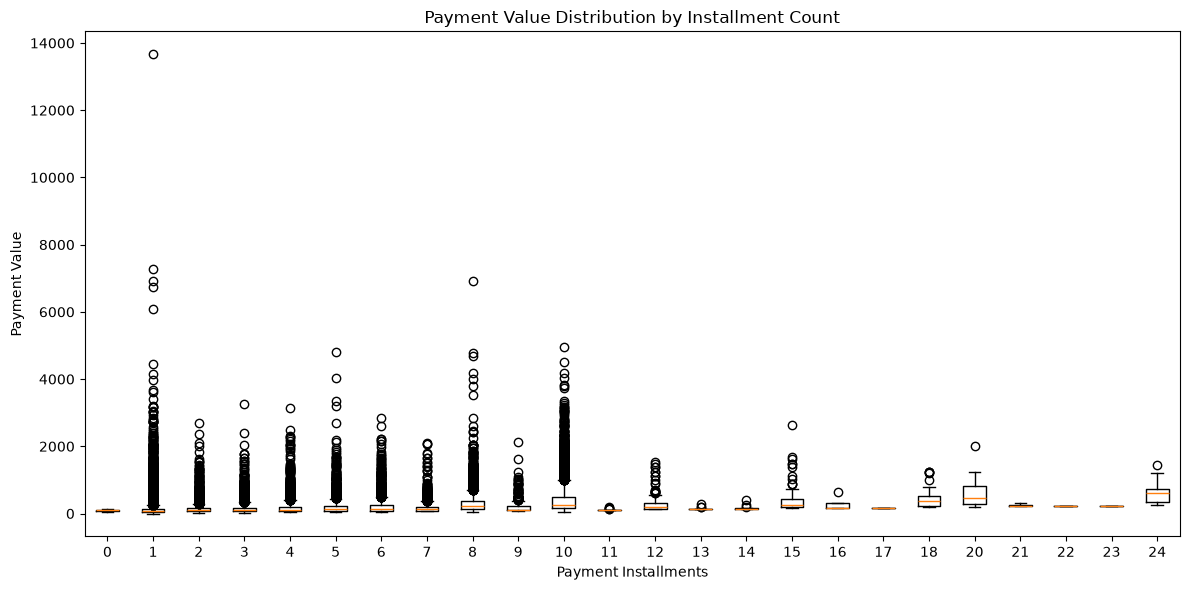

In [ ]:
plt.figure(figsize=(12, 6))

plt.boxplot(
    [
        payment_summary.loc[
            payment_summary["payment_installments"] == installment,
            "payment_value"
        ].dropna()
        for installment in sorted(
            payment_summary["payment_installments"].unique()
        )
    ],
    tick_labels=sorted(payment_summary["payment_installments"].unique())
)

plt.title("Payment Value Distribution by Installment Count")
plt.xlabel("Payment Installments")
plt.ylabel("Payment Value")

plt.tight_layout()
plt.show()

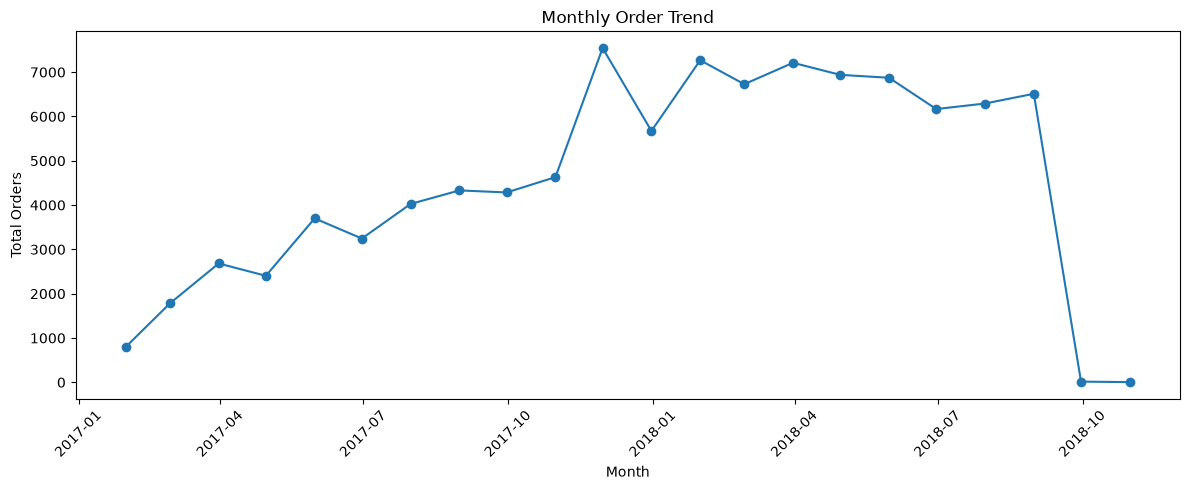

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["order_purchase_timestamp"],
    monthly_performance["Total_Orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

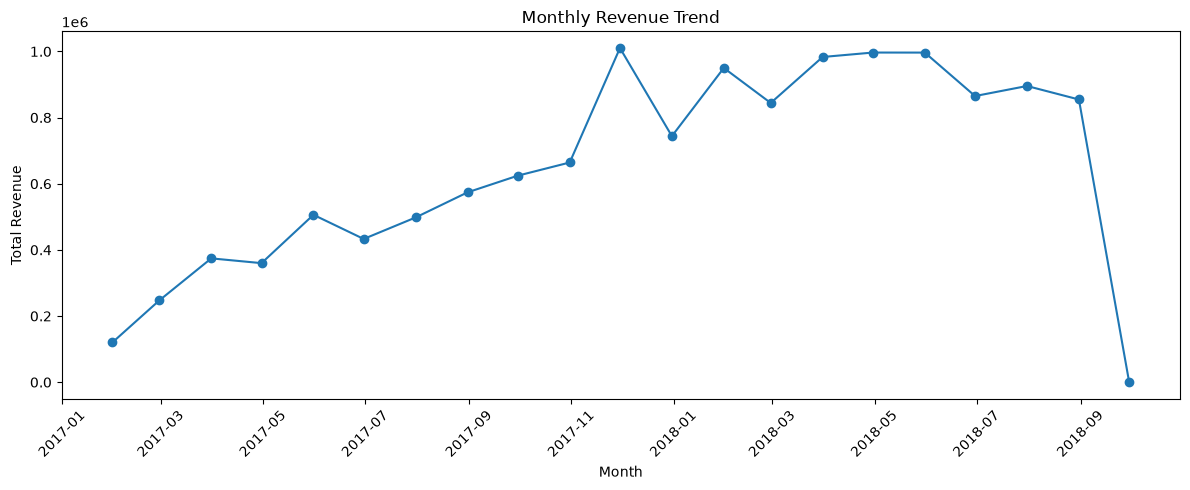

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["order_purchase_timestamp"],
    monthly_performance["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

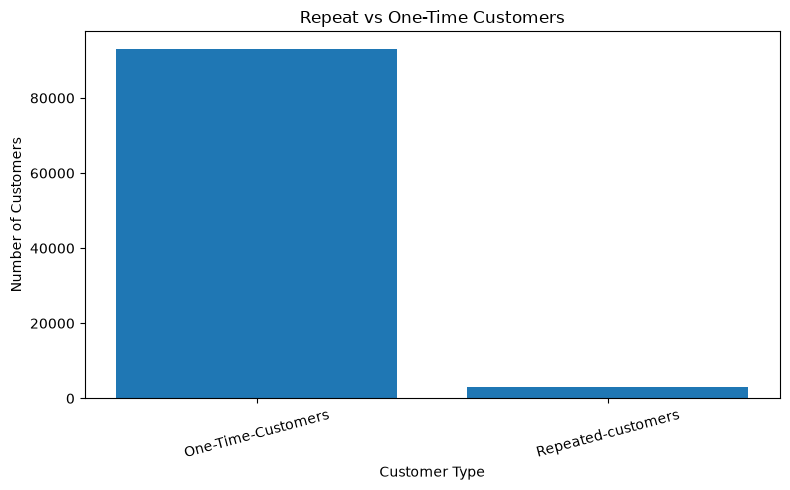

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    repeat_vs_onetime.index,
    repeat_vs_onetime["number_of_customers"]
)

plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

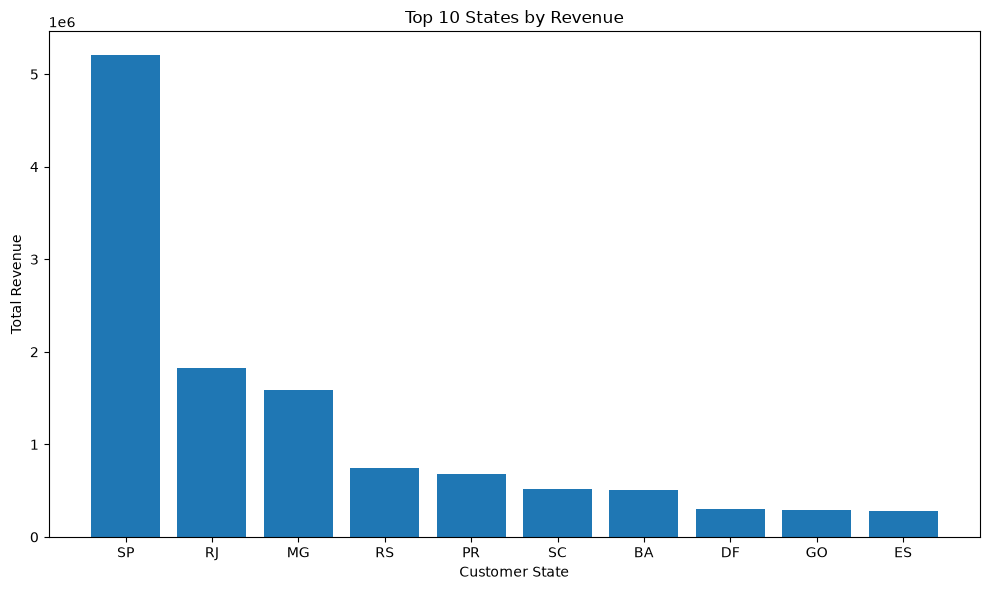

In [ ]:
top_10_states_revenue = (
    customer_state_analysis
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_states_revenue.index,
    top_10_states_revenue["revenue"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

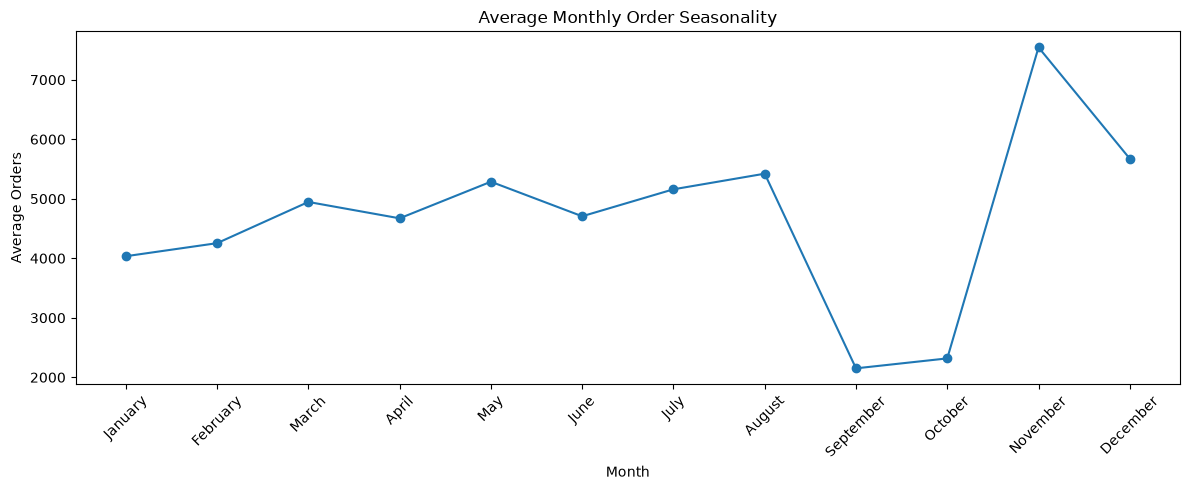

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    seasonality_analysis["Month_Name"],
    seasonality_analysis["Avg_Monthly_Orders"],
    marker="o"
)

plt.title("Average Monthly Order Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

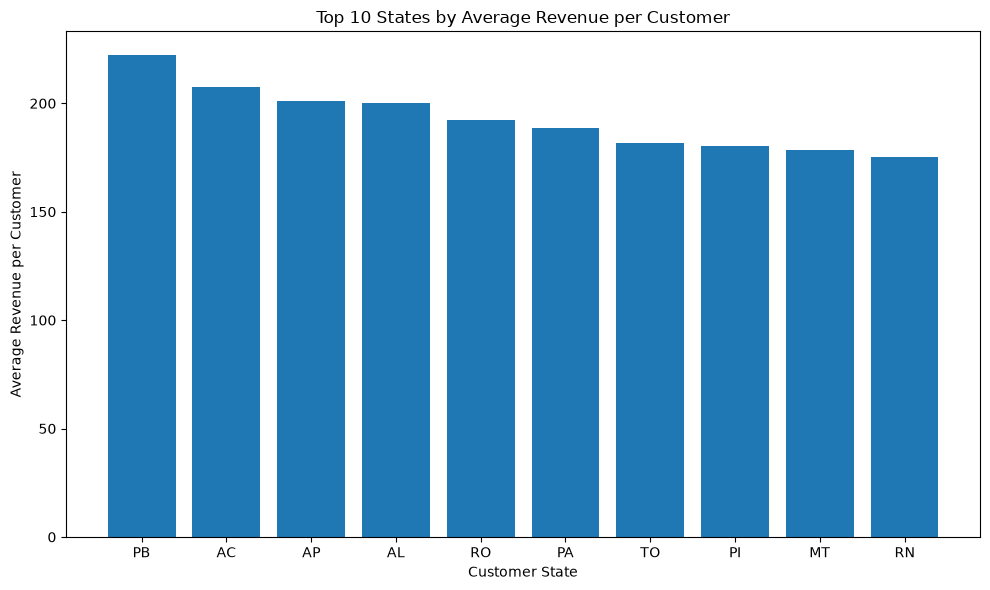

In [ ]:
plt.figure(figsize=(10, 6))

state_analysis_sorted = customer_state_analysis.sort_values(
    "avg_revenue_per_customer",
    ascending=False
).head(10)

plt.bar(
    state_analysis_sorted.index,
    state_analysis_sorted["avg_revenue_per_customer"]
)

plt.title("Top 10 States by Average Revenue per Customer")
plt.xlabel("Customer State")
plt.ylabel("Average Revenue per Customer")

plt.tight_layout()
plt.show()

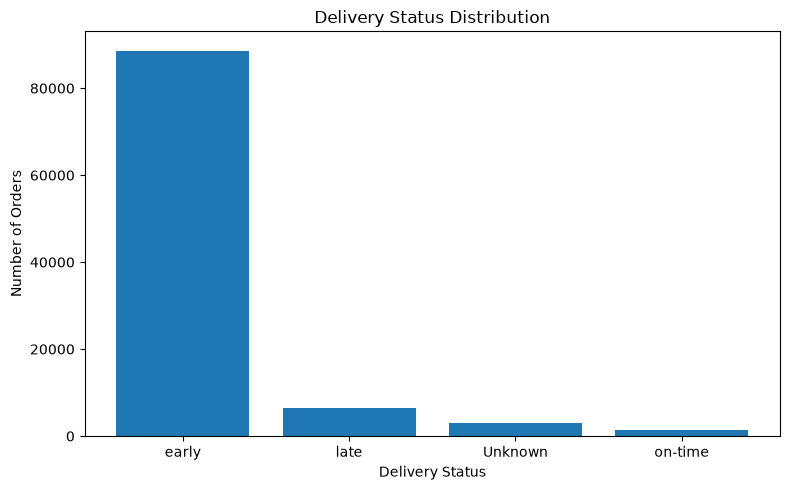

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_status_count.index,
    delivery_status_count.values
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

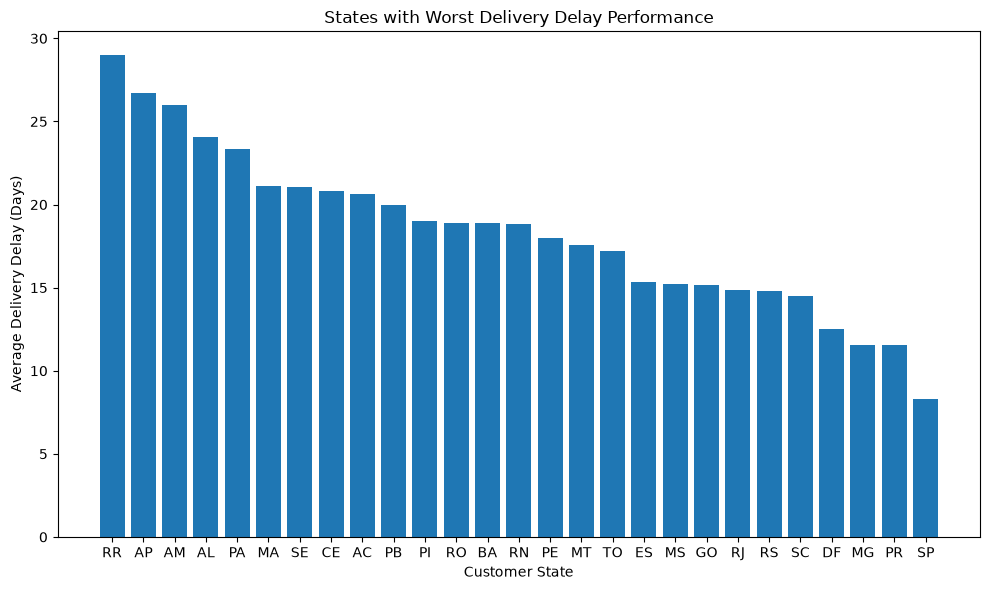

In [ ]:
worst_states = (
    customer_state_delivery_review
    .sort_values("delivery", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    worst_states.index,
    worst_states["delivery"]
)

plt.title("States with Worst Delivery Delay Performance")
plt.xlabel("Customer State")
plt.ylabel("Average Delivery Delay (Days)")

plt.tight_layout()
plt.show()

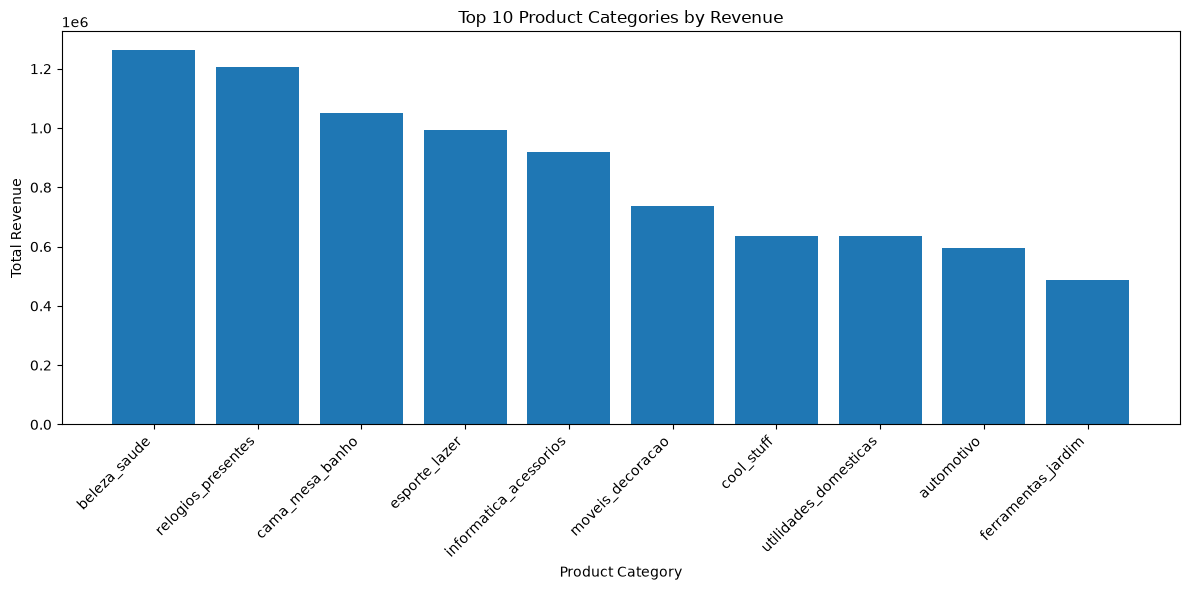

In [ ]:
top_10_categories = (
    category_business_performance
    .sort_values("Total_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_categories.index,
    top_10_categories["Total_revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

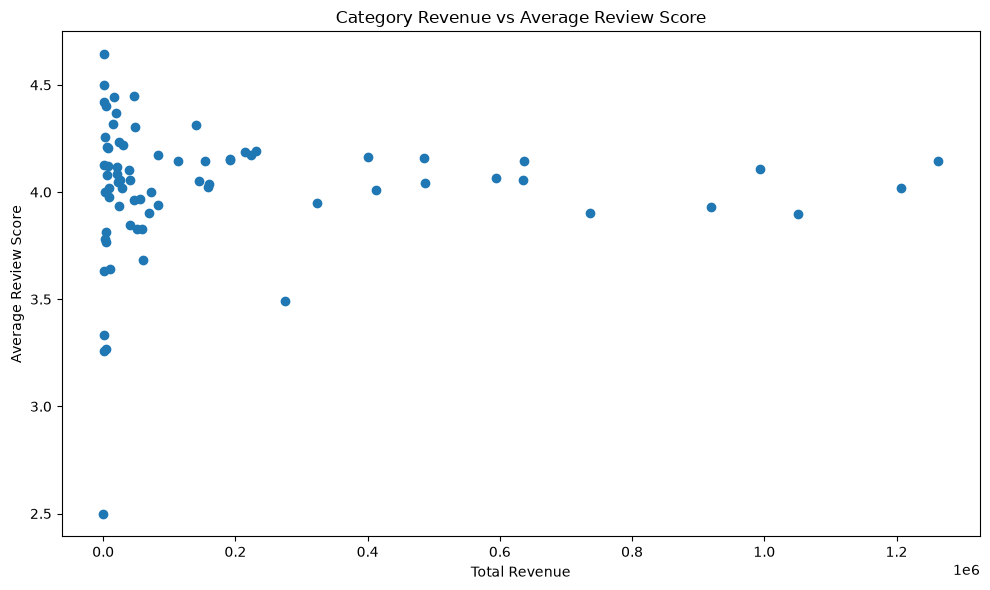

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    category_business_performance["Total_revenue"],
    category_business_performance["Avg_review_score"]
)

plt.title("Category Revenue vs Average Review Score")
plt.xlabel("Total Revenue")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

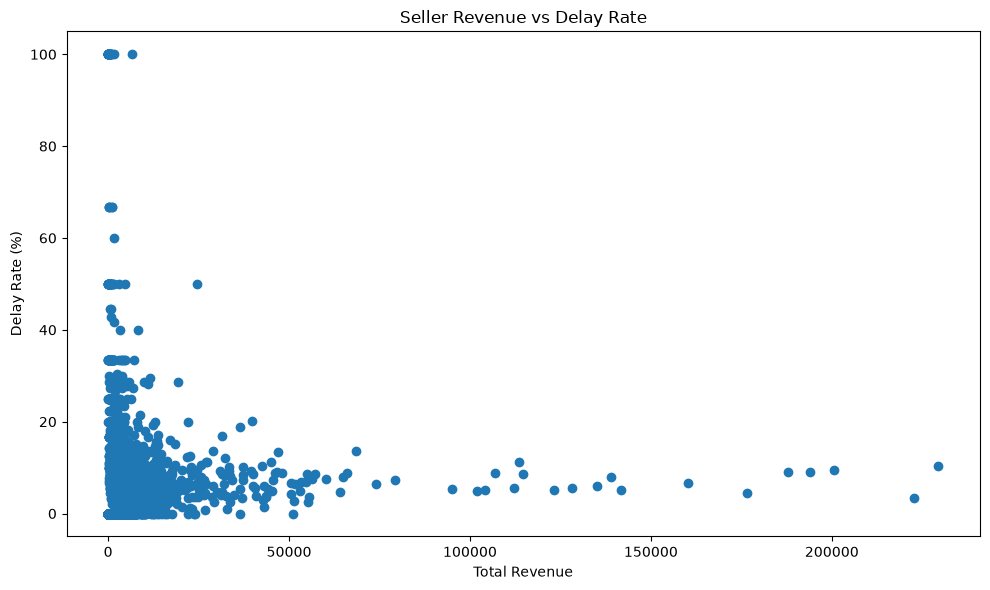

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    seller_summary["total_revenue"],
    seller_summary["delay_rate"]
)

plt.title("Seller Revenue vs Delay Rate")
plt.xlabel("Total Revenue")
plt.ylabel("Delay Rate (%)")

plt.tight_layout()
plt.show()

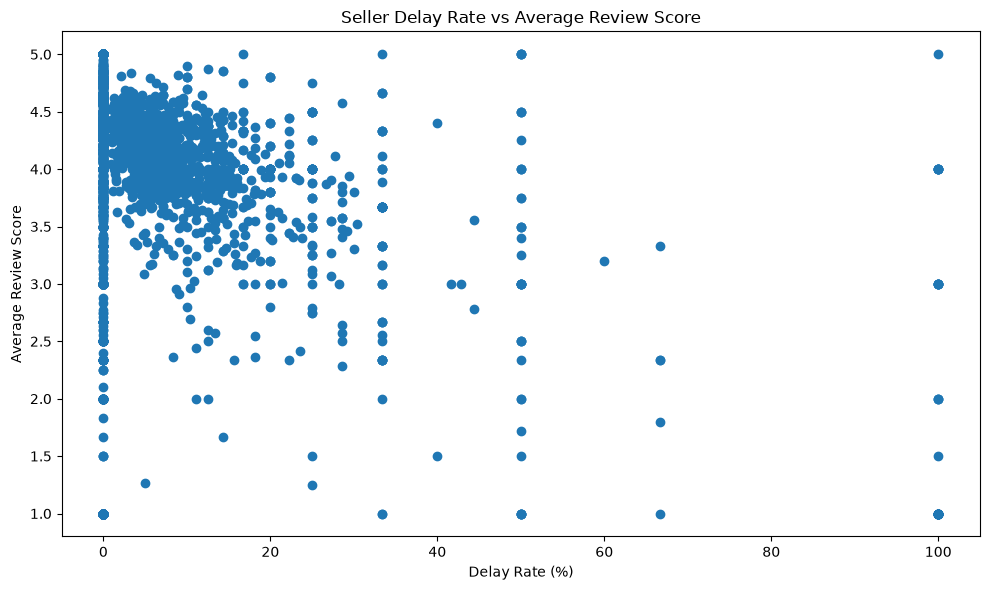

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    seller_summary["delay_rate"],
    seller_summary["average_review_score"]
)

plt.title("Seller Delay Rate vs Average Review Score")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

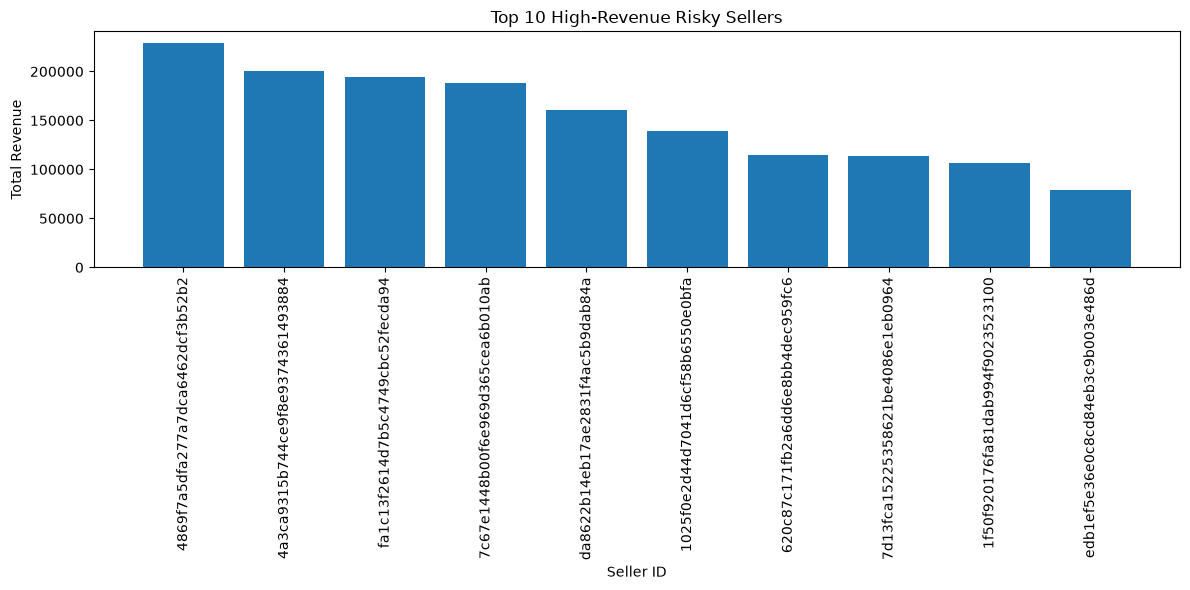

In [ ]:
top_risky_sellers = (
    risky_seller
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_risky_sellers.index,
    top_risky_sellers["total_revenue"]
)

plt.title("Top 10 High-Revenue Risky Sellers")
plt.xlabel("Seller ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

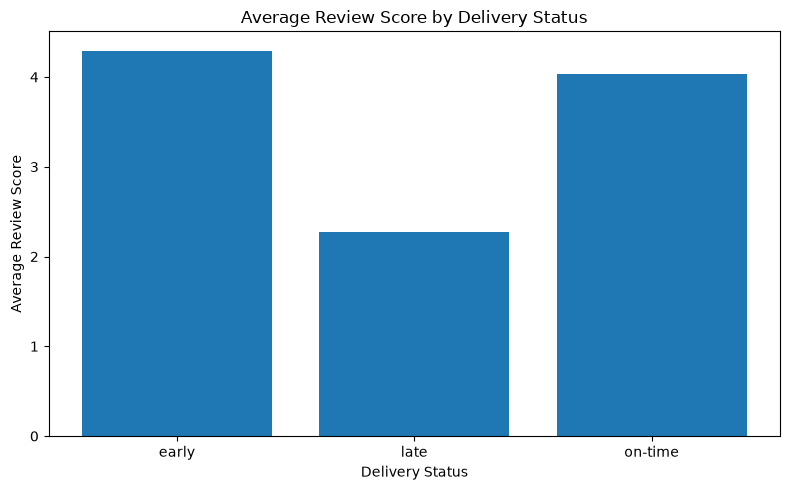

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_status_performance.index,
    delivery_status_performance["avg_review_score"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

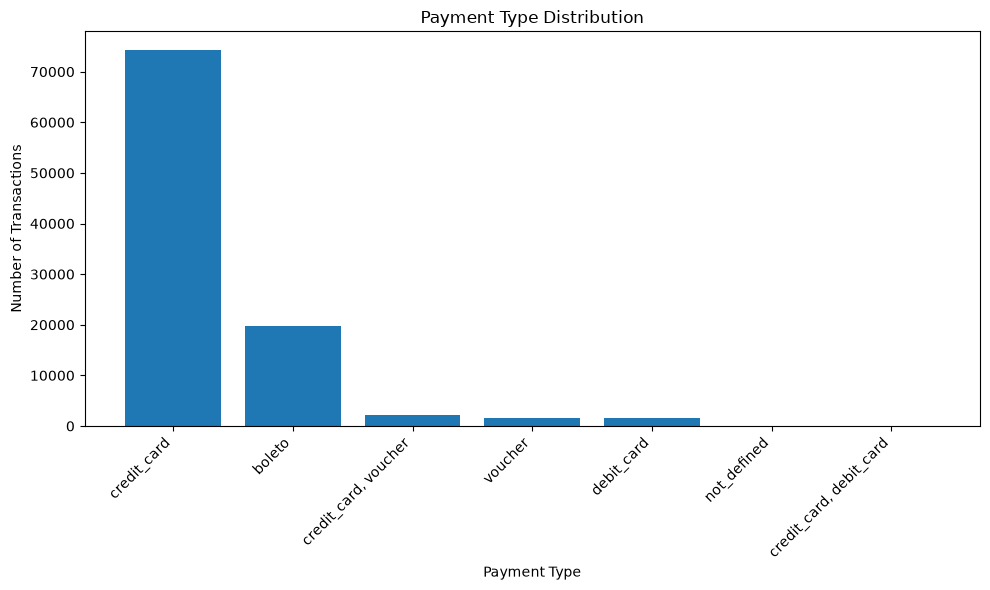

In [ ]:
payment_type_distribution = (
    payment_performance
    .sort_values("Total_transaction", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    payment_type_distribution.index,
    payment_type_distribution["Total_transaction"]
)

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

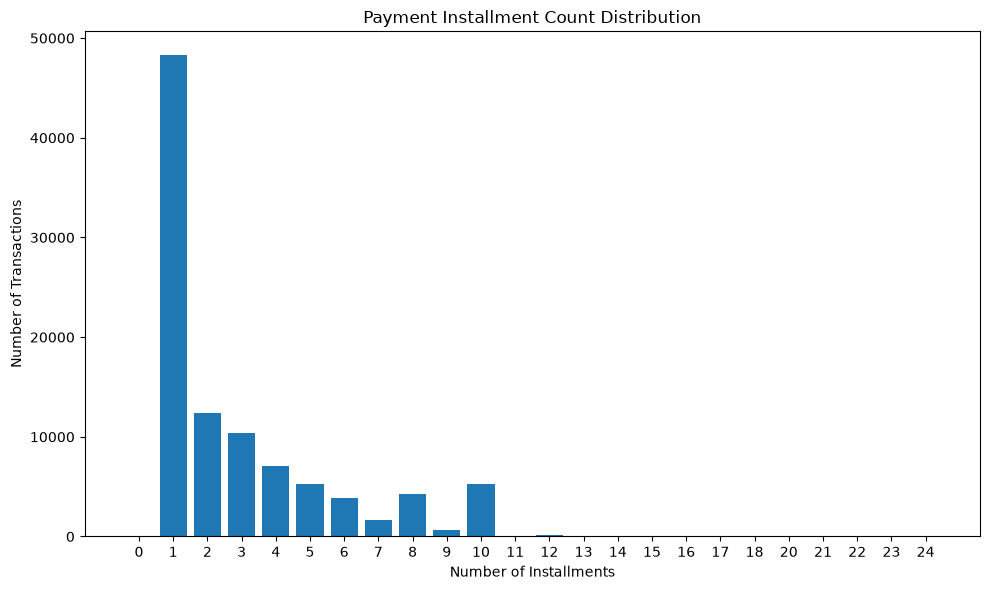

In [ ]:
installment_distribution = (
    payment_insatllment_performance
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    installment_distribution.index.astype(str),
    installment_distribution["Total_transaction"]
)

plt.title("Payment Installment Count Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()